In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, classification_report

In [2]:
pip install polars

Note: you may need to restart the kernel to use updated packages.


In [3]:
import polars as pl

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Training on: cuda
GPU: NVIDIA A100-PCIE-40GB


In [5]:
# plot helper
def plot_histogram(df, column, bins=50, title=None, xlabel=None, ylabel="Frequency", yscale ='linear'):
    if column not in df.columns:
        raise ValueError(f"Column '{column}' not found in DataFrame.")

    plt.figure()
    plt.hist(df[column], bins=bins, edgecolor='black')
    plt.title(title or f"Histogram of {column}")
    plt.xlabel(xlabel or column)
    plt.ylabel(ylabel)
    plt.yscale(yscale)
    plt.grid(True)
    plt.show()

def plot_histogram_by_type(df, value_column, type_column="type", bins=50, alpha=0.7, filename = 'default_file', title = None):
    if value_column not in df.columns or type_column not in df.columns:
        raise ValueError(f"Columns '{value_column}' and/or '{type_column}' not found in DataFrame.")

    # Compute shared bin edges from entire column
    data = df[value_column].dropna()
    bin_edges = np.linspace(data.min(), data.max(), bins + 1)

    plt.figure(figsize=(8, 6))

    for t in df[type_column].unique():
        subset = df[df[type_column] == t][value_column].dropna()
        plt.hist(subset, bins=bin_edges, alpha=alpha, label=t, edgecolor='black', histtype='stepfilled')

    plt.xlabel(value_column)
    plt.ylabel("Frequency")
    plt.yscale('log')
    title = title or f"Histogram of {value_column} by {type_column} from {filename}"
    plt.title(title)
    plt.legend(title=type_column)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [6]:
def print_nan_counts(df):
    """
    Counts and prints the number of NaN values in each column of a DataFrame.
    Only columns with at least one NaN are displayed.
    """
    # Count the number of NaNs in each column
    nan_counts = df.isna().sum()
    
    # Filter the series to only include columns where the count is greater than 0
    missing_data = nan_counts[nan_counts > 0]
    
    # Check if the filtered series is empty
    if missing_data.empty:
        print("No NaN values found in any column.")
    else:
        print("NaN counts per column:")
        print("-" * 20)
        print(missing_data)
        
    # Optional: return the filtered series in case you need it for further analysis
    return missing_data

In [7]:
df_sig = pl.read_parquet("../active_data/df_sig_truth_mu.parquet").to_pandas()
df_bkg = pl.read_parquet("../active_data/df_bkg_truth_mu.parquet").to_pandas()
print(df_sig.head())
print(df_bkg.head())

        MET    METPhi   fatJetPt  fatJetEta  fatJetPhi    fatJetM  fatJetD2  \
0  45.14351 -0.217958  261.75895  -0.791755  -0.169850  93.951730  0.170492   
1  38.37507 -0.572817  336.78653  -1.178040  -0.018764  65.684790  0.159118   
2  91.80720 -2.801607  204.19228   0.489402  -2.523493  84.227164  0.110668   
3  97.36711  1.225158  686.02475  -0.210825   1.275960  57.264426  0.073513   
4  31.64283  1.684687  276.79460   0.575572   1.703022  90.903780  0.204345   

   numOfInDetTracks_inFJCone  numOfFatJets     jet1Pt  ...  fj_track28dR  \
0                       26.0           1.0  391.86288  ...           NaN   
1                       28.0           1.0  241.49878  ...      0.712214   
2                       22.0           1.0  297.96928  ...           NaN   
3                       18.0           1.0  901.69744  ...           NaN   
4                       17.0           1.0  296.10610  ...           NaN   

   fj_track29dEta  fj_track29dPhi  fj_track29dR  fj_track30dEta  \
0

In [8]:
df_sig = df_sig[df_sig['fatJetPt']>200]
df_bkg = df_bkg[df_bkg['fatJetPt']>200]

In [9]:
df_sig = df_sig[df_sig['muon_fatjet_dr']<1]
df_bkg = df_bkg[df_bkg['muon_fatjet_dr']<1]

In [10]:
df_sig = df_sig[df_sig['fatJetM']>40]
df_bkg = df_bkg[df_bkg['fatJetM']>40]

In [11]:
import pandas as pd
import numpy as np

def delta_phi(phi1, phi2):
    """Calculates dPhi and wraps it strictly between -pi and pi."""
    dphi = phi1 - phi2
    return (dphi + np.pi) % (2 * np.pi) - np.pi

def delta_r(eta1, eta2, phi1, phi2):
    """Calculates standard dR."""
    deta = eta1 - eta2
    dphi = delta_phi(phi1, phi2)
    return np.sqrt(deta**2 + dphi**2)

def sort_jets_by_dr(df):
    """
    Computes dR for jet1 and jet2 relative to the fat jet.
    Swaps jet1 and jet2 properties so that jet1 always has the larger dR.
    """
    # Create a copy to avoid SettingWithCopyWarnings
    df = df.copy()

    # 1. Compute dR for jet1 and jet2 relative to fatJet
    dR1 = delta_r(df['jet1Eta'], df['fatJetEta'], df['jet1Phi'], df['fatJetPhi'])
    dR2 = delta_r(df['jet2Eta'], df['fatJetEta'], df['jet2Phi'], df['fatJetPhi'])

    # 2. Create a boolean mask identifying exactly which rows need swapping.
    # We want decreasing order (jet1_dR >= jet2_dR). 
    # Therefore, we swap where dR1 < dR2.
    swap_mask = dR1 < dR2

    # 3. Define the base variables that need to be swapped
    variables_to_swap = ['Pt', 'Eta', 'Phi', 'M']

    # 4. Perform the swap using np.where for blazing fast vectorization
    for var in variables_to_swap:
        j1_col = f'jet1{var}'
        j2_col = f'jet2{var}'
        
        # Store original jet1 values temporarily
        temp_j1 = df[j1_col].copy()
        
        # Where swap_mask is True, assign jet2's value to jet1. Otherwise, keep jet1.
        df[j1_col] = np.where(swap_mask, df[j2_col], df[j1_col])
        
        # Where swap_mask is True, assign the ORIGINAL jet1's value to jet2. Otherwise, keep jet2.
        df[j2_col] = np.where(swap_mask, temp_j1, df[j2_col])

    # 5. Optional but highly recommended: Save the correctly sorted dR values directly 
    # to the dataframe so you don't have to recompute them later!
    df['jet1_fatJet_dR'] = np.where(swap_mask, dR2, dR1)
    df['jet2_fatJet_dR'] = np.where(swap_mask, dR1, dR2)

    return df

In [12]:
# df_sig_sorted = sort_jets_by_dr(df_sig)
# df_bkg_sorted = sort_jets_by_dr(df_bkg)

In [13]:
# Filter out the dummy -999 values
df_sig = df_sig[df_sig['fatJetD2'] != -999]
df_bkg = df_bkg[df_bkg['fatJetD2'] != -999]

# # Quick check to see how many rows were dropped
# print(f"Signal events remaining: {len(df_sig_sorted)}")
# print(f"Background events remaining: {len(df_bkg_sorted)}")

In [14]:
# print("dr <1 cut")
# df_sig_dr_1 = df_sig_sorted[df_sig_sorted['muon_fatjet_dr']<1.0]

# print("sig_event_loss = ", 1-(len(df_sig_dr_1)/len(df_sig_sorted)), "sig_event_count =", len(df_sig_dr_1))
# df_bkg_dr_1 = df_bkg_sorted[df_bkg_sorted['muon_fatjet_dr']<1.0]

# print("sig_event_loss =", 1-(len(df_bkg_dr_1)/len(df_bkg_sorted)), "bkg_event_count =", len(df_bkg_dr_1))

In [15]:
if 'weight' in df_sig.keys() and 'weight' in df_bkg.keys():
    print("lalal")

    N_total = len(df_sig)+len(df_bkg)
    
    # 2. Calculate the current sums
    sum_w_sig = np.sum(df_sig['weight'])
    sum_w_bkg = np.sum(df_bkg['weight'])
    
    # 3. Scale them so each class sums to N_total / 2
    df_sig['weight'] = df_sig['weight'] * ((N_total / 2.0) / sum_w_sig)
    df_bkg['weight'] = df_bkg['weight'] * ((N_total / 2.0) / sum_w_bkg)
    
    # --- Verification ---
    print(f"Sum of Signal weights: {np.sum(df_sig['weight']):.1f}") # Should be N/2
    print(f"Sum of Bkg weights: {np.sum(df_bkg['weight']):.1f}")    # Should be N/2


    
else:    
    print("no weight available")
    sig_wt = (len(df_sig)+len(df_bkg))/len(df_sig)/2
    bkg_wt = (len(df_sig)+len(df_bkg))/len(df_bkg)/2
    df_sig['weight'] = sig_wt
    df_bkg['weight'] = bkg_wt

lalal
Sum of Signal weights: 128275.5
Sum of Bkg weights: 128275.5


In [16]:
# old version

In [17]:
def delta_phi_numpy(phi1, phi2):
    dphi = np.asarray(phi1) - np.asarray(phi2)
    dphi = np.where(dphi > np.pi, dphi - 2 * np.pi, dphi)
    dphi = np.where(dphi < -np.pi, dphi + 2 * np.pi, dphi)
    return dphi

def load_and_process_new_dataset(df, label_val, weight_scale=None, dr_threshold=1.5, dnn_features=None):
    """
    Processes the new flattened dataset for the combined GDNN model.
    """
    print(f"Initial events: {len(df)}")
    
    # --- 1. Event Filtering ---
    if 'muon_fatjet_dr' in df.columns:
        df = df[df['muon_fatjet_dr'] < dr_threshold].copy()
        print(f"  -> Events after muon_fatjet_dr < {dr_threshold} filter: {len(df)}")
    
    df = df.fillna(0.0).reset_index(drop=True)

    # --- 2. DNN Feature Engineering (Relative Geometry) ---
    
    # Jet 1 relative to Muon
    df['muon_jet1_deta'] = df['muonEta'] - df['jet1Eta']
    df['muon_jet1_dphi'] = delta_phi_numpy(df['muonPhi'], df['jet1Phi'])
    df['muon_jet1_dr'] = np.sqrt(df['muon_jet1_deta']**2 + df['muon_jet1_dphi']**2)

    # Jet 2 relative to Muon
    df['muon_jet2_deta'] = df['muonEta'] - df['jet2Eta']
    df['muon_jet2_dphi'] = delta_phi_numpy(df['muonPhi'], df['jet2Phi'])
    df['muon_jet2_dr'] = np.sqrt(df['muon_jet2_deta']**2 + df['muon_jet2_dphi']**2)

    # MET relative to Muon and FatJet
    df['muon_MET_dphi'] = delta_phi_numpy(df['muonPhi'], df['METPhi'])
    df['fatjet_MET_dphi'] = delta_phi_numpy(df['fatJetPhi'], df['METPhi'])

    # --- 3. GNN Tensor Construction ---
    MAX_TRACKS = 30
    pts = np.zeros((len(df), MAX_TRACKS))
    etas = np.zeros((len(df), MAX_TRACKS))
    phis = np.zeros((len(df), MAX_TRACKS))
    
    for i in range(1, MAX_TRACKS + 1):
        if f'fj_track{i}Pt' in df.columns:
            pts[:, i-1] = df[f'fj_track{i}Pt'].values
            etas[:, i-1] = df[f'fj_track{i}Eta'].values
            phis[:, i-1] = df[f'fj_track{i}Phi'].values
            
    # Extract FatJet kinematics and expand dimensions for broadcasting to (N_events, 1)
    fatJetPt = df['fatJetPt'].values[:, np.newaxis]
    fatJetEta = df['fatJetEta'].values[:, np.newaxis]
    fatJetPhi = df['fatJetPhi'].values[:, np.newaxis]
    
    # Create a mask to identify real tracks vs. padded zeros
    valid_mask = (pts != 0)
    
    # 1. Compute Relative Pt (Constituent Pt / FatJet Pt)
    rel_pts = np.divide(pts, fatJetPt, out=np.zeros_like(pts), where=(fatJetPt!=0))
    
    # 2. Compute delta Eta (detas)
    detas = etas - fatJetEta
    detas = np.where(valid_mask, detas, 0.0)
    
    # 3. Compute delta Phi (dphis) and wrap bounded to [-pi, pi]
    dphis = phis - fatJetPhi
    dphis = (dphis + np.pi) % (2 * np.pi) - np.pi
    dphis = np.where(valid_mask, dphis, 0.0)
    
    # 4. Compute delta R (drs)
    drs = np.sqrt(detas**2 + dphis**2)
    drs = np.where(valid_mask, drs, 0.0)
    
    # GNN Shape: (N_events, MAX_TRACKS, 4) -> Assuming MAX_TRACKS is 30
    X_gnn = np.stack([rel_pts, detas, dphis, drs], axis=-1).astype(np.float32)

    # --- 4. DNN Feature Selection & Tensor Construction ---
    if dnn_features is not None:
        missing = [c for c in dnn_features if c not in df.columns]
        if missing:
            print(f"  Note: Missing requested DNN columns (filled with 0): {missing}")
            for c in missing:
                df[c] = 0.0
        
        X_dnn = df[dnn_features].values.astype(np.float32)
        print(f"  -> Selected {len(dnn_features)} specific DNN features.")
    else:
        # Fallback
        dnn_cols = df.select_dtypes(include=[np.number]).columns.tolist()
        X_dnn = df[dnn_cols].values.astype(np.float32)

    # --- 5. Finalize Labels, Weights, and IDs ---
    n_events = len(df)
    if 'label' in df.columns:
        y = df['label'].values
    else:
        y = np.full(n_events, label_val, dtype=np.float32)
    
    if weight_scale is None:
        w = df['weight'].values
    else:
        w = np.full(n_events, weight_scale, dtype=np.float32)
    
    if 'event_index' in df.columns:
        ids = df['event_index'].values
    else:
        ids = np.arange(n_events)

    print(f"  -> Finished formatting: GNN shape: {X_gnn.shape}, DNN shape: {X_dnn.shape}")
    
    return X_gnn, X_dnn, y, w, ids

In [18]:
# # NEW version with reordered GNN
# # Helper function for angle wrapping
# def delta_phi_numpy(phi1, phi2):
#     dphi = np.asarray(phi1) - np.asarray(phi2)
#     dphi = np.where(dphi > np.pi, dphi - 2 * np.pi, dphi)
#     dphi = np.where(dphi < -np.pi, dphi + 2 * np.pi, dphi)
#     return dphi

# def load_and_process_new_dataset(df, label_val, weight_scale=None, dr_threshold=1.5, dnn_features=None):
#     """
#     Processes the new flattened dataset for the combined GDNN model.
#     Tracks are sorted based on (rel_pt^2 + (1-dr)^2).
#     """
#     print(f"Initial events: {len(df)}")
    
#     # --- 1. Event Filtering ---
#     if 'muon_fatjet_dr' in df.columns:
#         df = df[df['muon_fatjet_dr'] < dr_threshold].copy()
#         print(f"  -> Events after muon_fatjet_dr < {dr_threshold} filter: {len(df)}")
    
#     df = df.fillna(0.0).reset_index(drop=True)

#     # --- 2. DNN Feature Engineering (Relative Geometry) ---
    
#     # Jet 1 relative to Muon
#     df['muon_jet1_deta'] = df['muonEta'] - df['jet1Eta']
#     df['muon_jet1_dphi'] = delta_phi_numpy(df['muonPhi'], df['jet1Phi'])
#     df['muon_jet1_dr'] = np.sqrt(df['muon_jet1_deta']**2 + df['muon_jet1_dphi']**2)

#     # Jet 2 relative to Muon
#     df['muon_jet2_deta'] = df['muonEta'] - df['jet2Eta']
#     df['muon_jet2_dphi'] = delta_phi_numpy(df['muonPhi'], df['jet2Phi'])
#     df['muon_jet2_dr'] = np.sqrt(df['muon_jet2_deta']**2 + df['muon_jet2_dphi']**2)

#     # MET relative to Muon and FatJet
#     df['muon_MET_dphi'] = delta_phi_numpy(df['muonPhi'], df['METPhi'])
#     df['fatjet_MET_dphi'] = delta_phi_numpy(df['fatJetPhi'], df['METPhi'])

#     # --- 3. GNN Tensor Construction & Sorting ---
#     MAX_TRACKS = 30
#     pts = np.zeros((len(df), MAX_TRACKS))
#     detas = np.zeros((len(df), MAX_TRACKS))
#     dphis = np.zeros((len(df), MAX_TRACKS))
#     drs = np.zeros((len(df), MAX_TRACKS))
    
#     for i in range(1, MAX_TRACKS + 1):
#         if f'fj_track{i}Pt' in df.columns:
#             pts[:, i-1] = df[f'fj_track{i}Pt'].values
#             detas[:, i-1] = df[f'fj_track{i}dEta'].values
#             dphis[:, i-1] = df[f'fj_track{i}dPhi'].values
#             drs[:, i-1] = df[f'fj_track{i}dR'].values

#     # GNN Shape: (N_events, 30, 4)
#     X_gnn = np.stack([pts, detas, dphis, drs], axis=-1).astype(np.float32)

#     # --- 4. DNN Feature Selection & Tensor Construction ---
#     if dnn_features is not None:
#         missing = [c for c in dnn_features if c not in df.columns]
#         if missing:
#             print(f"  Note: Missing requested DNN columns (filled with 0): {missing}")
#             for c in missing:
#                 df[c] = 0.0
        
#         X_dnn = df[dnn_features].values.astype(np.float32)
#         print(f"  -> Selected {len(dnn_features)} specific DNN features.")
#     else:
#         # Fallback
#         dnn_cols = df.select_dtypes(include=[np.number]).columns.tolist()
#         X_dnn = df[dnn_cols].values.astype(np.float32)

#     # --- 5. Finalize Labels, Weights, and IDs ---
#     n_events = len(df)
#     y = np.full(n_events, label_val, dtype=np.float32)
    
#     if weight_scale is None:
#         w = df['weight'].values
#     else:
#         w = np.full(n_events, weight_scale, dtype=np.float32)
    
#     if 'event_index' in df.columns:
#         ids = df['event_index'].values
#     else:
#         ids = np.arange(n_events)

#     print(f"  -> Finished formatting: GNN shape: {X_gnn.shape}, DNN shape: {X_dnn.shape}")
    
#     return X_gnn, X_dnn, y, w, ids

In [19]:

my_dnn_features = [
    # Global / Track Counts
    #'numOfInDetTracks_inFJCone', 'fatJetD2',
    
    # Muon Base Kinematics (Keeping Eta as the spatial reference point)
    'muonPt', 'muonEta', 
    
    # FatJet Base Kinematics
    'fatJetPt', 'fatJetM', 'fatJetEta', 
    
    # Small Jets Base Kinematics
    'jet1Pt', 'jet1M','jet2Pt', 'jet2M',
    
    # MET Base
    'MET',
    
    # Pre-existing Relative Geometries
    'muon_fatjet_dr', 'muon_fatjet_deta', 'muon_fatjet_dphi',
    
    # Newly Engineered Relative Geometries
    'muon_jet1_dr', 'muon_jet1_deta', 'muon_jet1_dphi',
    
    'muon_jet2_dr', 'muon_jet2_deta', 'muon_jet2_dphi',
    
    'muon_MET_dphi', 'fatjet_MET_dphi'
]

# 3. Process the data
xg_sig, xd_sig, y_sig, w_sig, id_sig = load_and_process_new_dataset(
    df_sig, 
    label_val=1, 
    weight_scale=None, 
    dr_threshold=1.0, 
    dnn_features=my_dnn_features
)

xg_bg, xd_bg, y_bg, w_bg, id_bg = load_and_process_new_dataset(
    df_bkg, 
    label_val=0, 
    weight_scale=None, 
    dr_threshold=1.0, 
    dnn_features=my_dnn_features
)

# 4. Concatenate and move to your PyTorch DataLoader
X_gnn_all = np.concatenate([xg_sig, xg_bg], axis=0)
X_dnn_all = np.concatenate([xd_sig, xd_bg], axis=0)

Initial events: 174344
  -> Events after muon_fatjet_dr < 1.0 filter: 174344
  -> Selected 21 specific DNN features.
  -> Finished formatting: GNN shape: (174344, 30, 4), DNN shape: (174344, 21)
Initial events: 82207
  -> Events after muon_fatjet_dr < 1.0 filter: 82207
  -> Selected 21 specific DNN features.
  -> Finished formatting: GNN shape: (82207, 30, 4), DNN shape: (82207, 21)


In [20]:
SCORED_PARQUET_SIG = "sig_truth.parquet"
SCORED_PARQUET_BKG = "bkg_truth.parquet"

In [22]:
# DNN

In [22]:
import pandas as pd

# 1. Replicate the EXACT filtering applied in load_and_process_new_dataset
dr_threshold = 1.0

# Process Signal DataFrame
df_sig_filtered = df_sig[df_sig['muon_fatjet_dr'] < dr_threshold].copy()
df_sig_filtered = df_sig_filtered.fillna(0.0).reset_index(drop=True)
df_sig_filtered['label'] = 1  # Keep track of the label

# Process Background DataFrame
df_bkg_filtered = df_bkg[df_bkg['muon_fatjet_dr'] < dr_threshold].copy()
df_bkg_filtered = df_bkg_filtered.fillna(0.0).reset_index(drop=True)
df_bkg_filtered['label'] = 0  # Keep track of the label

# 2. Concatenate in the EXACT same order as np.concatenate([y_sig, y_bg])
# ignore_index=True ensures the row indices go exactly from 0 to len(y_all)-1
df_all_combined = pd.concat([df_sig_filtered, df_bkg_filtered], ignore_index=True)

# 3. Use the test_idx array from train_test_split to slice the combined dataframe
df_test = df_all_combined.iloc[test_idx].copy()

# 4. Reset index for the final test set
df_test = df_test.reset_index(drop=True)

print(f"Total Concatenated DataFrame size: {len(df_all_combined)} (Should match {len(y_all)})")
print(f"Final Test DataFrame size: {len(df_test)} (Should match {len(test_idx)})")
print(f"Number of Signal events in test set: {(df_test['label'] == 1).sum()}")
print(f"Number of Background events in test set: {(df_test['label'] == 0).sum()}")

# View the result
display(df_test.head())

Total Concatenated DataFrame size: 256551 (Should match 256551)
Final Test DataFrame size: 25656 (Should match 25656)
Number of Signal events in test set: 17435
Number of Background events in test set: 8221


,MET,METPhi,fatJetPt,fatJetEta,fatJetPhi,fatJetM,fatJetD2,numOfInDetTracks_inFJCone,numOfFatJets,jet1Pt,...,fj_track29dEta,fj_track29dPhi,fj_track29dR,fj_track30dEta,fj_track30dPhi,fj_track30dR,event_index,__index_level_0__,weight,label
0,49.937695,-2.564802,406.80616,0.998934,-1.892991,189.97383,0.233499,63.0,1.0,306.65066,...,-0.101410,-0.802709,0.809089,-0.038484,0.0496,0.062779,598869,212119,0.735761,1
1,60.940830,-1.028134,216.92720,-1.384528,-0.456537,90.66019,0.281496,29.0,1.0,270.20466,...,-0.392705,-0.239221,0.459830,0.000000,0.0000,0.000000,22564,7979,0.735761,1
2,41.878210,-0.810113,303.95170,0.022309,-0.168400,84.78944,0.123746,25.0,1.0,235.50684,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,2391569,847003,0.735761,1
3,116.609030,2.239376,208.25127,-0.226948,2.316529,97.49286,0.188765,29.0,1.0,212.77388,...,0.726880,0.668517,0.987558,0.000000,0.0000,0.000000,1500495,532009,0.735761,1
4,15.879657,-2.471985,221.63262,1.849271,-2.866462,93.74768,0.143598,16.0,1.0,225.70098,...,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,1333084,472475,0.735761,1


In [23]:
xg_test, xd_test, y_test, w_test, id_test = load_and_process_new_dataset(
    df_test, 
    label_val=2, 
    weight_scale=None, 
    dr_threshold=1.0, 
    dnn_features=my_dnn_features
)

Initial events: 25656
  -> Events after muon_fatjet_dr < 1.0 filter: 25656
  -> Selected 21 specific DNN features.
  -> Finished formatting: GNN shape: (25656, 30, 4), DNN shape: (25656, 21)


In [21]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc, classification_report
import matplotlib.pyplot as plt
import time
import os

OUTPUT_DIR = 'dnn_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128

# 1. Finish Concatenation
X_gnn_all = np.concatenate([xg_sig, xg_bg], axis=0)
X_dnn_all = np.concatenate([xd_sig, xd_bg], axis=0)
y_all = np.concatenate([y_sig, y_bg], axis=0)
w_all = np.concatenate([w_sig, w_bg], axis=0)
# id_all = np.concatenate([id_sig, id_bg], axis=0) # If you need to track IDs

print(f"Total dataset size: {len(y_all)} events")

# 2. Scale DNN Features
scaler_dnn = StandardScaler()
X_dnn_all_scaled = scaler_dnn.fit_transform(X_dnn_all)

# 3. Data Splitting (Train 80% / Val 10% / Test 10%)
indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

# 4. PyTorch Datasets
train_ds = TensorDataset(
    torch.tensor(X_dnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.tensor(y_all[train_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[train_idx], dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.tensor(X_dnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.tensor(y_all[val_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[val_idx], dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.tensor(X_dnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.tensor(y_all[test_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[test_idx], dtype=torch.float32).view(-1, 1)
)

# 5. DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

Total dataset size: 256551 events


In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
# Make sure to import the scheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau 

class DNN_Only(nn.Module):
    def __init__(self, input_dim):
        super(DNN_Only, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), 
            nn.ReLU(), 
            nn.BatchNorm1d(128), 
            nn.Dropout(0.15),
            
            nn.Linear(128, 64), 
            nn.ReLU(), 
            nn.BatchNorm1d(64), 
            nn.Dropout(0.15),
            
            nn.Linear(64, 32), 
            nn.ReLU(),
            
            nn.Linear(32, 1) # Outputs logits
        )
        
    def forward(self, x):
        return self.net(x)

# Initialize Model
input_features = X_dnn_all_scaled.shape[1] # Should be 25
dnn_model = DNN_Only(input_dim=input_features).to(DEVICE)

# Compile for A100 speedup (Optional but recommended)
try:
    dnn_model = torch.compile(dnn_model)
    print("Model compiled successfully.")
except Exception as e:
    print(f"Skipping torch.compile: {e}")

optimizer = optim.Adam(dnn_model.parameters(), lr=0.001)

# --- NEW: Initialize the Scheduler ---
# mode='min': We want to reduce LR when the metric (val_loss) stops decreasing.
# factor=0.5: When triggered, the new LR will be LR * 0.5.
# patience=2: Wait 2 epochs of no improvement before dropping the LR.
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

scaler = torch.amp.GradScaler('cuda')

def weighted_bce_loss(output, target, weight):
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    weighted_loss = loss * weight
    # Divide by the sum of weights to get a true weighted average
    return weighted_loss.sum() / (weight.sum() + 1e-8)

Model compiled successfully.


In [25]:
print("\nStarting DNN Training...")
EPOCHS = 80 
best_val_loss = float('inf')
patience = 12
epochs_no_improve = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- Training ---
    dnn_model.train()
    train_loss = 0
    
    for x_batch, y_batch, w_batch in train_loader:
        x_batch = x_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        w_batch = w_batch.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            out = dnn_model(x_batch)
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * x_batch.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # --- Validation ---
    dnn_model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for x_batch, y_batch, w_batch in val_loader:
            x_batch = x_batch.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            w_batch = w_batch.to(DEVICE, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                out = dnn_model(x_batch)
                loss = weighted_bce_loss(out, y_batch, w_batch)
            
            val_loss += loss.item() * x_batch.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    # --- NEW: Step the Scheduler ---
    # Pass the validation loss to the scheduler so it can check for plateaus
    scheduler.step(val_loss)
    
    # Grab the current learning rate from the optimizer to print it
    current_lr = optimizer.param_groups[0]['lr']
    
    # Updated print statement to show the current learning rate
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Time: {time.time() - start_time:.1f}s")
    
    # --- Early Stopping Logic ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(dnn_model.state_dict(), f"{OUTPUT_DIR}/best_dnn_only.pth")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered! Training stopped at epoch {epoch+1}.")
            break

print("Training Complete!")


Starting DNN Training...
Epoch [1/80] | Train Loss: 0.3132 | Val Loss: 0.2270 | LR: 0.001000 | Time: 11.4s
Epoch [2/80] | Train Loss: 0.2493 | Val Loss: 0.2174 | LR: 0.001000 | Time: 6.8s
Epoch [3/80] | Train Loss: 0.2338 | Val Loss: 0.2094 | LR: 0.001000 | Time: 6.7s
Epoch [4/80] | Train Loss: 0.2262 | Val Loss: 0.2048 | LR: 0.001000 | Time: 6.7s
Epoch [5/80] | Train Loss: 0.2214 | Val Loss: 0.1977 | LR: 0.001000 | Time: 6.7s
Epoch [6/80] | Train Loss: 0.2190 | Val Loss: 0.1999 | LR: 0.001000 | Time: 6.7s
  -> No improvement for 1 epoch(s).
Epoch [7/80] | Train Loss: 0.2159 | Val Loss: 0.1918 | LR: 0.001000 | Time: 6.8s
Epoch [8/80] | Train Loss: 0.2145 | Val Loss: 0.1968 | LR: 0.001000 | Time: 6.7s
  -> No improvement for 1 epoch(s).
Epoch [9/80] | Train Loss: 0.2116 | Val Loss: 0.1970 | LR: 0.001000 | Time: 6.7s
  -> No improvement for 2 epoch(s).
Epoch [10/80] | Train Loss: 0.2104 | Val Loss: 0.1927 | LR: 0.001000 | Time: 6.7s
  -> No improvement for 3 epoch(s).
Epoch [11/80] | Tr


Evaluating best model on Test Set...


/tmp/ipykernel_2853/3002952453.py:82: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_dnn_only.pth"))



FINAL PERFORMANCE ON TEST SET (with event weights)
              precision    recall  f1-score   support

  Background       0.95      0.90      0.93 13363.615883350372
      Signal       0.91      0.95      0.93 12827.991765737534

    accuracy                           0.93 26191.607649087906
   macro avg       0.93      0.93      0.93 26191.607649087906
weighted avg       0.93      0.93      0.93 26191.607649087906



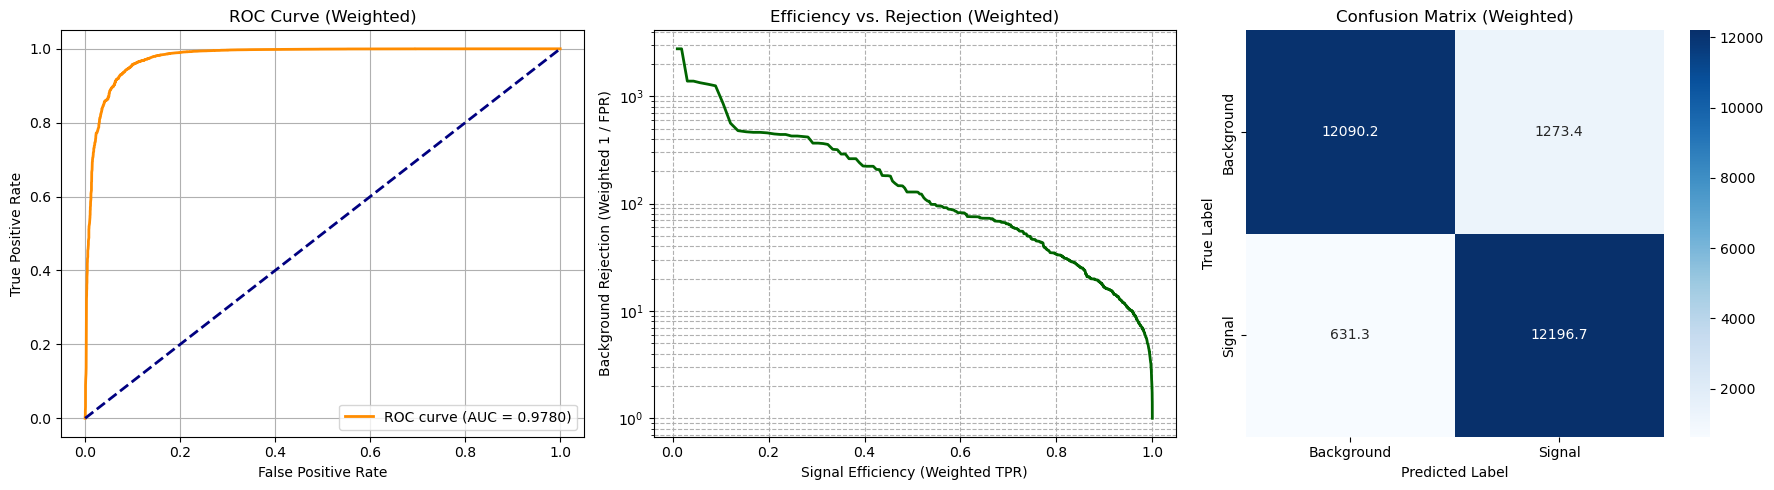


SCORING AND SAVING FULL DATASETS


/tmp/ipykernel_2853/3002952453.py:130: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  dnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_dnn_only.pth"))


<All keys matched successfully>

In [26]:
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

# ==========================================
# 4. Evaluation Function
# ==========================================
def evaluate_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()  # Set model to evaluation mode
    all_labels = []
    all_probas = []
    all_weights = [] # Collect weights for evaluation metrics if needed

    with torch.no_grad():
        for inputs, labels, weights in data_loader:
            inputs = inputs.to(device)
            
            # Use autocast for mixed precision evaluation
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                # Apply sigmoid since the model outputs logits
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy()) # Collect weights

    # Flatten arrays for scikit-learn functions
    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten()

    # 1. Performance Statistics (using sample_weight)
    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET (with event weights)\n" + "="*60)
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    # 2. ROC Curve (using sample_weight)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Weighted)')
    plt.legend(loc="lower right")
    plt.grid(True)

    # 3. Signal Efficiency vs. Background Rejection (calculated from weighted FPR/TPR)
    # Avoid division by zero warnings
    with np.errstate(divide='ignore'):
        background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
        
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log')
    plt.xlabel('Signal Efficiency (Weighted TPR)')
    plt.ylabel('Background Rejection (Weighted 1 / FPR)')
    plt.title('Efficiency vs. Rejection (Weighted)')
    plt.grid(True, which="both", ls="--")

    # 4. Confusion Matrix (using sample_weight)
    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) 
    plt.title('Confusion Matrix (Weighted)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

# --- Execution ---
print("\nEvaluating best model on Test Set...")
# Load the best weights saved by the early stopping mechanism
dnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_dnn_only.pth"))

# Call the function
evaluate_model(dnn_model, test_loader, DEVICE)

# 5. Score Entire Datasets and Save to Parquet
# ==========================================
import os

def score_and_save_dataset(df, X_dnn_raw, scaler, model, device, output_path, batch_size=BATCH_SIZE):
    """
    Applies the trained model to the full dataset, adds the scores as a new column,
    and saves the result to a Parquet file.
    """
    print(f"Generating scores for {len(df)} events...")
    
    # 1. Scale the raw features using the ALREADY FITTED scaler
    X_scaled = scaler.transform(X_dnn_raw)
    
    # 2. Create a DataLoader for batch processing (safeguard against GPU OOM)
    tensor_ds = TensorDataset(torch.tensor(X_scaled, dtype=torch.float32))
    loader = DataLoader(tensor_ds, batch_size=batch_size, shuffle=False)
    
    # 3. Get predictions
    model.eval()
    all_probas = []
    
    with torch.no_grad():
        for (inputs,) in loader:
            inputs = inputs.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                probas = torch.sigmoid(outputs)
            all_probas.extend(probas.cpu().numpy())
            
    # 4. Add the scores to a copy of the dataframe
    df_scored = df.copy() 
    df_scored['dnn_score'] = np.array(all_probas).flatten()
    
    # 5. Save to Parquet
    df_scored.to_parquet(output_path, engine='pyarrow', index=False)
    print(f" -> Saved successfully to: {output_path}")
    
    return df_scored

print("\n" + "="*60 + "\nSCORING AND SAVING FULL DATASETS\n" + "="*60)

# Ensure the model is using the best weights
dnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_dnn_only.pth"))

# Score Signal Dataset
# # Note: df_sig_dr_1 and xd_sig are from your earlier load_and_process_new_dataset calls
# df_sig_scored = score_and_save_dataset(
#     df=df_sig, 
#     X_dnn_raw=xd_sig, 
#     scaler=scaler_dnn, 
#     model=dnn_model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_SIG),
#     batch_size=BATCH_SIZE
# )

# # Score Background Dataset
# df_bkg_scored = score_and_save_dataset(
#     df=df_bkg, 
#     X_dnn_raw=xd_bg, 
#     scaler=scaler_dnn, 
#     model=dnn_model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_BKG),
#     batch_size=BATCH_SIZE
# )

# print("\nAll processing complete.")




In [27]:
df_test_scored = score_and_save_dataset(
    df=df_test, 
    X_dnn_raw=xd_test, 
    scaler=scaler_dnn, 
    model=dnn_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, "test_df.parquet"),
    batch_size=BATCH_SIZE
)

Generating scores for 25656 events...
 -> Saved successfully to: dnn_results/test_df.parquet


In [28]:
#GNN Model

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import os

OUTPUT_DIR = 'gnn_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ==========================================
# 1. GNN Data Preparation & Scaling
# ==========================================
# Assuming xg_sig, xg_bg, y_sig, y_bg, w_sig, w_bg are in memory
X_gnn_all = np.concatenate([xg_sig, xg_bg], axis=0)
X_dnn_all = np.concatenate([xd_sig, xd_bg], axis=0)
y_all = np.concatenate([y_sig, y_bg], axis=0)
w_all = np.concatenate([w_sig, w_bg], axis=0)

print(f"Total GNN dataset size: {len(y_all)} events")

# Scale GNN Features (Masking out zero-padded particles)
N, M, F = X_gnn_all.shape
X_gnn_flat = X_gnn_all.reshape(-1, F)
is_real = ~np.all(X_gnn_flat == 0, axis=1) # Boolean mask for real tracks

scaler_gnn = StandardScaler()
# Fit only on real particles
scaler_gnn.fit(X_gnn_flat[is_real])
# Transform real particles
X_gnn_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
# Ensure padding remains exactly zero
X_gnn_flat[~is_real] = 0 

X_gnn_all_scaled = X_gnn_flat.reshape(N, M, F)

# Data Splitting (Train 80% / Val 10% / Test 10%)
# Using same random_state=42 ensures the splits perfectly match the DNN splits later!
indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

# PyTorch Datasets
train_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.tensor(y_all[train_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[train_idx], dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.tensor(y_all[val_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[val_idx], dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.tensor(y_all[test_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[test_idx], dtype=torch.float32).view(-1, 1)
)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

Total GNN dataset size: 256551 events


In [30]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
# Make sure to import the scheduler
from torch.optim.lr_scheduler import ReduceLROnPlateau 

# ==========================================
# 2. Model Definition
# ==========================================
# --- Model Definition (Interaction Network) ---
def create_interaction_matrices(n_particles):
    # Receiver Matrix (RR) [N, N(N-1)]
    RR = np.zeros((n_particles, n_particles * (n_particles - 1)), dtype=np.float32)
    # Sender Matrix (RS) [N, N(N-1)]
    RS = np.zeros((n_particles, n_particles * (n_particles - 1)), dtype=np.float32)
    
    cnt = 0
    for i in range(n_particles):
        for j in range(n_particles):
            if i != j:
                RR[i, cnt] = 1.0
                RS[j, cnt] = 1.0
                cnt += 1
    return torch.tensor(RR), torch.tensor(RS)

class InteractionNetwork(nn.Module):
    def __init__(self, n_particles, n_features, output_dim=1):
        super(InteractionNetwork, self).__init__()
        
        # Interaction Matrices
        RR, RS = create_interaction_matrices(n_particles)
        self.register_buffer('RR', RR)
        self.register_buffer('RS', RS)
        
        # --- Relational Model (Edge Function) ---
        self.rel_layer1 = nn.Sequential(nn.Linear(2 * n_features, 80), nn.ReLU())
        self.rel_layer2 = nn.Sequential(nn.Linear(80, 50), nn.ReLU())
        self.rel_layer3 = nn.Sequential(nn.Linear(50, 30), nn.ReLU())
        self.rel_bn = nn.BatchNorm1d(30)
        
        # --- Object Model (Node Function) ---
        self.obj_layer1 = nn.Sequential(nn.Linear(n_features + 30, 80), nn.ReLU())
        self.obj_layer2 = nn.Sequential(nn.Linear(80, 50), nn.ReLU())
        self.obj_layer3 = nn.Sequential(nn.Linear(50, 24), nn.ReLU())
        
        # --- Classifier (Global) ---
        self.cls_layer1 = nn.Sequential(nn.Linear(24, 60), nn.ReLU())
        self.cls_bn = nn.BatchNorm1d(60)
        self.cls_layer2 = nn.Sequential(nn.Linear(60, 30), nn.ReLU())
        self.cls_layer3 = nn.Sequential(nn.Linear(30, 10), nn.ReLU())
        self.cls_out = nn.Linear(10, output_dim) 


    def forward(self, x):
        # --- NEW: Identify padded particles (where all features are exactly 0) ---
        # mask is 1 for real particles, 0 for padded particles
        valid_mask = (~(x == 0).all(dim=-1)).float().unsqueeze(-1) # Shape: [B, N, 1]

        x_transpose = x.transpose(1, 2)
        receivers = torch.matmul(x_transpose, self.RR)
        senders = torch.matmul(x_transpose, self.RS)
        edges = torch.cat([receivers, senders], dim=1).transpose(1, 2)
        
        e = self.rel_layer1(edges)
        e = self.rel_layer2(e)
        e = self.rel_layer3(e)
        
        e = e.transpose(1, 2) 
        e = self.rel_bn(e)
        e = e.transpose(1, 2) 
        
        effect_agg = torch.matmul(e.transpose(1, 2), self.RR.t()).transpose(1, 2)
        
        node_input = torch.cat([x, effect_agg], dim=2)
        node = self.obj_layer1(node_input)
        node = self.obj_layer2(node)
        node = self.obj_layer3(node) 
        
        # --- FIX: Multiply by the valid_mask before summing so biases are wiped to 0 ---
        node = node * valid_mask 
        
        # Output exactly the 24-dim graph embedding
        global_latent = torch.sum(node, dim=1)
        
        c = self.cls_layer1(global_latent)
        c = self.cls_bn(c)
        c = self.cls_layer2(c)
        c = self.cls_layer3(c)
        
        # Return RAW LOGITS (No Sigmoid here!) for numerical stability
        return self.cls_out(c)

# Initialize Model
# Features F=4 (rel_pt, dEta, dPhi, dR)
# DEVICE and OUTPUT_DIR should be defined elsewhere in your code
gnn_model = InteractionNetwork(n_particles=30, n_features=4).to(DEVICE)

try:
    gnn_model = torch.compile(gnn_model)
    print("GNN Model compiled successfully.")
except Exception as e:
    print(f"Skipping torch.compile.")

optimizer = optim.Adam(gnn_model.parameters(), lr=0.001)

# --- NEW: Initialize the Scheduler ---
# mode='min': Monitoring for decrease in val_loss
# factor=0.5: Halve the learning rate on plateau
# patience=3: Trigger after 3 epochs of no improvement (safely below early stopping patience of 8)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

scaler = torch.amp.GradScaler('cuda')

def weighted_bce_loss(output, target, weight):
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    return (loss * weight).mean()

GNN Model compiled successfully.


In [31]:
# ==========================================
# 3. Training Loop with Early Stopping
# ==========================================
print("\nStarting GNN Training...")
EPOCHS = 100 
best_val_loss = float('inf')
patience = 12
epochs_no_improve = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- Training ---
    gnn_model.train()
    train_loss = 0
    
    for x_batch, y_batch, w_batch in train_loader:
        x_batch = x_batch.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        w_batch = w_batch.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            out = gnn_model(x_batch)
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * x_batch.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # --- Validation ---
    gnn_model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for x_batch, y_batch, w_batch in val_loader:
            x_batch = x_batch.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            w_batch = w_batch.to(DEVICE, non_blocking=True)
            
            # REMOVED: with torch.amp.autocast('cuda'):
            # Run the forward pass in standard float32 for absolute stability
            out = gnn_model(x_batch)
            
            # Since everything is already float32, we can just calculate loss directly
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
            val_loss += loss.item() * x_batch.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    # --- NEW: Step the Scheduler ---
    # Pass val_loss to check for plateau
    scheduler.step(val_loss)
    
    # Grab the current learning rate from the optimizer
    current_lr = optimizer.param_groups[0]['lr']
    
    # Updated print statement to show the current learning rate
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Time: {time.time() - start_time:.1f}s")
    
    # --- Early Stopping Logic ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(gnn_model.state_dict(), f"{OUTPUT_DIR}/best_gnn_only.pth")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered! Training stopped at epoch {epoch+1}.")
            break

print("Training Complete!")


Starting GNN Training...


/opt/conda/lib/python3.12/site-packages/torch/_inductor/compile_fx.py:167: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


Epoch [1/100] | Train Loss: 0.5995 | Val Loss: 0.5848 | LR: 0.001000 | Time: 44.4s
Epoch [2/100] | Train Loss: 0.5813 | Val Loss: 0.5814 | LR: 0.001000 | Time: 10.1s
Epoch [3/100] | Train Loss: 0.5755 | Val Loss: 0.5714 | LR: 0.001000 | Time: 9.9s
Epoch [4/100] | Train Loss: 0.5724 | Val Loss: 0.5743 | LR: 0.001000 | Time: 10.0s
  -> No improvement for 1 epoch(s).
Epoch [5/100] | Train Loss: 0.5670 | Val Loss: 0.5639 | LR: 0.001000 | Time: 10.0s
Epoch [6/100] | Train Loss: 0.5625 | Val Loss: 0.5624 | LR: 0.001000 | Time: 10.2s
Epoch [7/100] | Train Loss: 0.5575 | Val Loss: 0.5597 | LR: 0.001000 | Time: 10.1s
Epoch [8/100] | Train Loss: 0.5545 | Val Loss: 0.5715 | LR: 0.001000 | Time: 10.1s
  -> No improvement for 1 epoch(s).
Epoch [9/100] | Train Loss: 0.5510 | Val Loss: 0.5538 | LR: 0.001000 | Time: 10.1s
Epoch [10/100] | Train Loss: 0.5475 | Val Loss: 0.5482 | LR: 0.001000 | Time: 11.0s
Epoch [11/100] | Train Loss: 0.5444 | Val Loss: 0.5529 | LR: 0.001000 | Time: 9.9s
  -> No improve


Evaluating best GNN model on Test Set...


/tmp/ipykernel_2853/3480109618.py:58: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gnn_only.pth"))



FINAL PERFORMANCE ON TEST SET (with event weights)
              precision    recall  f1-score   support

  Background       0.73      0.77      0.75 13363.615883350372
      Signal       0.75      0.70      0.72 12827.991765737534

    accuracy                           0.74 26191.607649087906
   macro avg       0.74      0.74      0.74 26191.607649087906
weighted avg       0.74      0.74      0.74 26191.607649087906



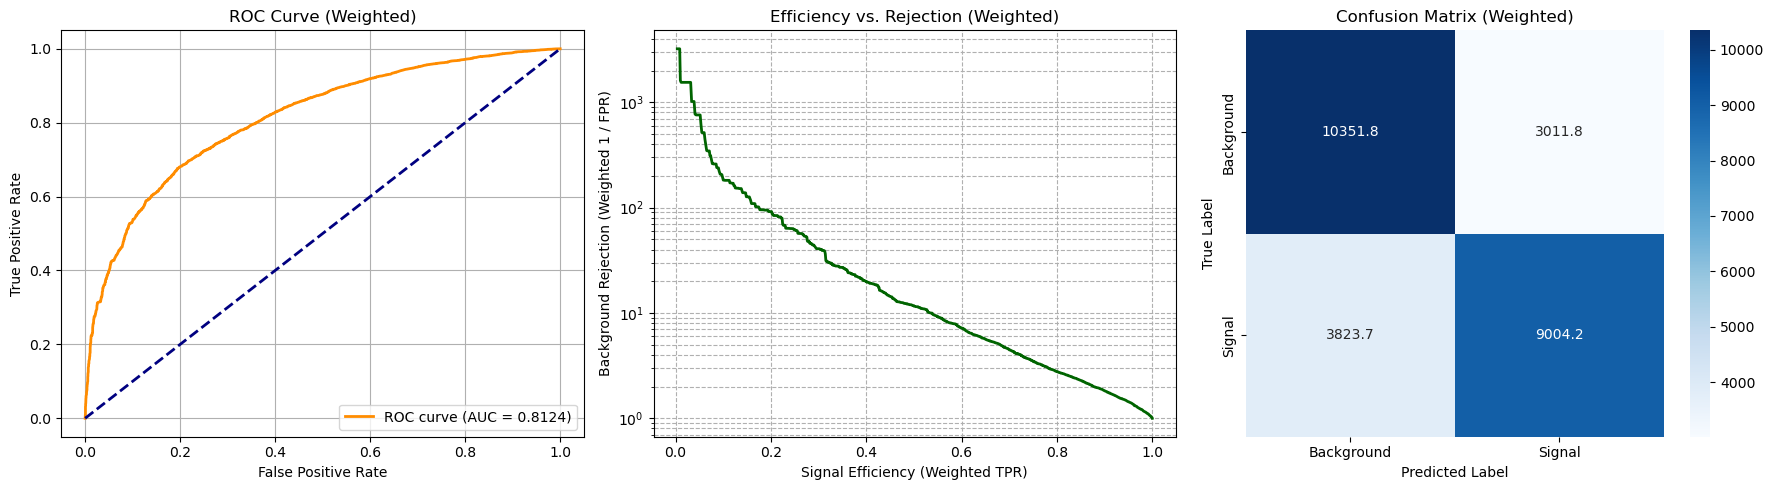


SCORING AND SAVING FULL DATASETS (GNN)


/tmp/ipykernel_2853/3480109618.py:122: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gnn_only.pth"))


<All keys matched successfully>

In [32]:
# ==========================================
# 4. Evaluation Function
# ==========================================
def evaluate_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()  # Set model to evaluation mode
    all_labels = []
    all_probas = []
    all_weights = [] # Collect weights for evaluation metrics if needed

    with torch.no_grad():
        for inputs, labels, weights in data_loader:
            inputs = inputs.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy()) # Collect weights

    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten() # Flatten weights for scikit-learn functions

    # 1. Performance Statistics (using sample_weight)
    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET (with event weights)\n" + "="*60)
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    # 2. ROC Curve (using sample_weight)
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(18, 5))
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve (Weighted)'); plt.legend(loc="lower right"); plt.grid(True)

    # 3. Signal Efficiency vs. Background Rejection (calculated from weighted FPR/TPR)
    with np.errstate(divide='ignore'):
        background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log'); plt.xlabel('Signal Efficiency (Weighted TPR)'); plt.ylabel('Background Rejection (Weighted 1 / FPR)'); plt.title('Efficiency vs. Rejection (Weighted)'); plt.grid(True, which="both", ls="--")

    # 4. Confusion Matrix (using sample_weight)
    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) 
    plt.title('Confusion Matrix (Weighted)'); plt.ylabel('True Label'); plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

# --- Execution ---
print("\nEvaluating best GNN model on Test Set...")
gnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gnn_only.pth"))

# Call the function
evaluate_model(gnn_model, test_loader, DEVICE)

# ==========================================
# 5. Score Entire Datasets and Save to Parquet
# ==========================================
import os

def score_and_save_gnn_dataset(df, X_gnn_raw, scaler, model, device, output_path, batch_size=BATCH_SIZE):
    """
    Applies the trained GNN model to the full dataset, adds the scores as a new column,
    and saves the result to a Parquet file.
    """
    print(f"Generating GNN scores for {len(df)} events...")
    
    # 1. Scale the raw features using the ALREADY FITTED scaler
    # Must replicate the masking logic used during training data prep
    N, M, F = X_gnn_raw.shape
    X_flat = X_gnn_raw.reshape(-1, F).copy()  # Copy to avoid modifying original array
    
    # Create mask for real tracks (not perfectly zeroed out)
    is_real = ~np.all(X_flat == 0, axis=1)
    
    # Apply transform only to real tracks
    if np.any(is_real):
        X_flat[is_real] = scaler.transform(X_flat[is_real])
        
    # Ensure padding remains exactly zero
    X_flat[~is_real] = 0.0 
    
    # Reshape back to (N_events, 30, 4)
    X_scaled = X_flat.reshape(N, M, F)
    
    # 2. Create a DataLoader for batch processing
    tensor_ds = TensorDataset(torch.tensor(X_scaled, dtype=torch.float32))
    loader = DataLoader(tensor_ds, batch_size=batch_size, shuffle=False)
    
    # 3. Get predictions
    model.eval()
    all_probas = []
    
    with torch.no_grad():
        for (inputs,) in loader:
            inputs = inputs.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                probas = torch.sigmoid(outputs)
            all_probas.extend(probas.cpu().numpy())
            
    # 4. Add the scores to a copy of the dataframe
    df_scored = df.copy() 
    df_scored['gnn_score'] = np.array(all_probas).flatten()
    
    # 5. Save to Parquet
    df_scored.to_parquet(output_path, engine='pyarrow', index=False)
    print(f" -> Saved successfully to: {output_path}")
    
    return df_scored

print("\n" + "="*60 + "\nSCORING AND SAVING FULL DATASETS (GNN)\n" + "="*60)

# Ensure the model is using the best weights from Early Stopping
gnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gnn_only.pth"))

# Score Signal Dataset
# Assuming df_sig_dr_1 and xg_sig are in memory from your data processing step
# df_sig_gnn_scored = score_and_save_gnn_dataset(
#     df=df_sig_scored, 
#     X_gnn_raw=xg_sig, 
#     scaler=scaler_gnn, 
#     model=gnn_model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_SIG),
#     batch_size=BATCH_SIZE
# )

# # Score Background Dataset
# df_bkg_gnn_scored = score_and_save_gnn_dataset(
#     df=df_bkg_scored, 
#     X_gnn_raw=xg_bg, 
#     scaler=scaler_gnn, 
#     model=gnn_model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_BKG),
#     batch_size=BATCH_SIZE
# )

# print("\nAll GNN processing complete.")



In [33]:
df_test_gnn_scored = score_and_save_gnn_dataset(
    df=df_test_scored, 
    X_gnn_raw=xg_test, 
    scaler=scaler_gnn, 
    model=gnn_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, "test_df.parquet"),
    batch_size=BATCH_SIZE
)

Generating GNN scores for 25656 events...
 -> Saved successfully to: gnn_results/test_df.parquet


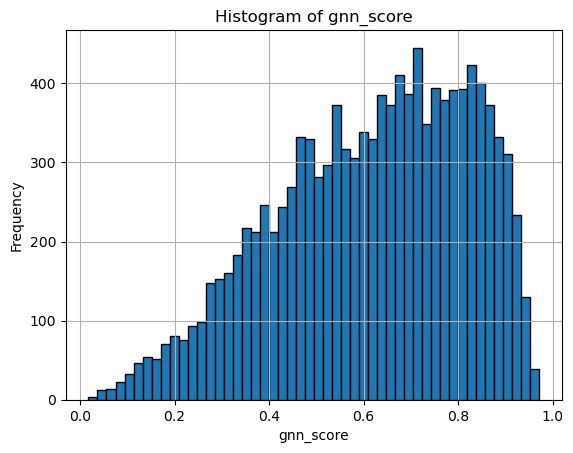

In [179]:
plot_histogram(df_test_gnn_scored[df_test_gnn_scored['label']==1], 'gnn_score')

In [ ]:
#GDNN

In [34]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import os

OUTPUT_DIR = 'gdnn_combined_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")



# ==========================================
# 1. Combined Data Preparation
# ==========================================
# Assuming X_gnn_all_scaled, X_dnn_all_scaled, y_all, w_all are in memory
print(f"Total Combined dataset size: {len(y_all)} events")

indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

# PyTorch Datasets (Yielding: x_gnn, x_dnn, y, w)
train_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.tensor(y_all[train_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[train_idx], dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.tensor(y_all[val_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[val_idx], dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.tensor(y_all[test_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[test_idx], dtype=torch.float32).view(-1, 1)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

Total Combined dataset size: 256551 events


In [35]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import numpy as np
# --- NEW: Make sure to import the scheduler ---
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ==========================================
# 2. Model Definition
# ==========================================
class InteractionNetwork(nn.Module):
    def __init__(self, n_particles, n_features, output_latent_dim=24):
        super(InteractionNetwork, self).__init__()
        
        # Interaction Matrices
        RR = np.zeros((n_particles, n_particles * (n_particles - 1)), dtype=np.float32)
        RS = np.zeros((n_particles, n_particles * (n_particles - 1)), dtype=np.float32)
        cnt = 0
        for i in range(n_particles):
            for j in range(n_particles):
                if i != j:
                    RR[i, cnt] = 1.0
                    RS[j, cnt] = 1.0
                    cnt += 1
        self.register_buffer('RR', torch.tensor(RR))
        self.register_buffer('RS', torch.tensor(RS))
        
        # Relational Model
        self.rel_layer1 = nn.Sequential(nn.Linear(2 * n_features, 80), nn.ReLU())
        self.rel_layer2 = nn.Sequential(nn.Linear(80, 50), nn.ReLU())
        self.rel_layer3 = nn.Sequential(nn.Linear(50, 30), nn.ReLU())
        self.rel_bn = nn.BatchNorm1d(30)
        
        # Object Model
        self.obj_layer1 = nn.Sequential(nn.Linear(n_features + 30, 80), nn.ReLU())
        self.obj_layer2 = nn.Sequential(nn.Linear(80, 50), nn.ReLU())
        self.obj_layer3 = nn.Sequential(nn.Linear(50, output_latent_dim), nn.ReLU())
        
    def forward(self, x):
        # --- NEW: Identify padded particles (where all features are exactly 0) ---
        # mask is 1 for real particles, 0 for padded particles
        valid_mask = (~(x == 0).all(dim=-1)).float().unsqueeze(-1) # Shape: [B, N, 1]

        x_transpose = x.transpose(1, 2)
        receivers = torch.matmul(x_transpose, self.RR)
        senders = torch.matmul(x_transpose, self.RS)
        edges = torch.cat([receivers, senders], dim=1).transpose(1, 2)
        
        e = self.rel_layer1(edges)
        e = self.rel_layer2(e)
        e = self.rel_layer3(e)
        
        e = e.transpose(1, 2) 
        e = self.rel_bn(e)
        e = e.transpose(1, 2) 
        
        effect_agg = torch.matmul(e.transpose(1, 2), self.RR.t()).transpose(1, 2)
        
        node_input = torch.cat([x, effect_agg], dim=2)
        node = self.obj_layer1(node_input)
        node = self.obj_layer2(node)
        node = self.obj_layer3(node) 
        
        # --- FIX: Multiply by the valid_mask before summing so biases are wiped to 0 ---
        node = node * valid_mask 
        
        # Output exactly the 24-dim graph embedding
        global_latent = torch.sum(node, dim=1)
        return global_latent

class DNNBlock(nn.Module):
    def __init__(self, input_dim):
        super(DNNBlock, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.15),
            nn.Linear(128, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.15),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1) # Output Logits
        )
    def forward(self, x):
        return self.net(x)

class GDNN(nn.Module):
    def __init__(self, gnn_features, dnn_features, n_particles=30):
        super(GDNN, self).__init__()
        # GNN branch outputs a vector of size 24
        self.gnn = InteractionNetwork(n_particles, gnn_features, output_latent_dim=24)
        
        # DNN input = GNN_output (24) + Event_Kinematics (dnn_features)
        combined_dim = 24 + dnn_features
        self.dnn = DNNBlock(combined_dim)
        
    def forward(self, x_gnn, x_dnn):
        # 1. Get Graph Embedding
        graph_embedding = self.gnn(x_gnn)
        
        # 2. Concatenate with High-Level Features
        combined = torch.cat([graph_embedding, x_dnn], dim=1)
        
        # 3. Final Prediction
        logits = self.dnn(combined)
        return logits

# Initialize Model
# (Assuming X_gnn_all_scaled, X_dnn_all_scaled, DEVICE, OUTPUT_DIR are defined above)
gnn_feats = X_gnn_all_scaled.shape[2] # 4
dnn_feats = X_dnn_all_scaled.shape[1] # 25
gdnn_model = GDNN(gnn_feats, dnn_feats, n_particles=30).to(DEVICE)

try:
    gdnn_model = torch.compile(gdnn_model)
    print("GDNN Model compiled successfully.")
except Exception:
    print("Skipping torch.compile.")

optimizer = optim.Adam(gdnn_model.parameters(), lr=0.001)

# --- NEW: Initialize the Scheduler ---
# Trigger after 3 epochs of no improvement, halving the learning rate
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

scaler = torch.amp.GradScaler('cuda')

def weighted_bce_loss(output, target, weight):
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    weighted_loss = loss * weight
    return weighted_loss.sum() / (weight.sum() + 1e-8)

GDNN Model compiled successfully.


In [36]:
# ==========================================
# 3. Training Loop
# ==========================================
print("\nStarting GDNN Training...")
EPOCHS = 100 
best_val_loss = float('inf')
patience = 12
epochs_no_improve = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- Training ---
    gdnn_model.train()
    train_loss = 0
    
    for xg, xd, y_batch, w_batch in train_loader:
        xg = xg.to(DEVICE, non_blocking=True)
        xd = xd.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        w_batch = w_batch.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            out = gdnn_model(xg, xd)
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * xg.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # --- Validation ---
    gdnn_model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for xg, xd, y_batch, w_batch in val_loader:
            xg = xg.to(DEVICE, non_blocking=True)
            xd = xd.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            w_batch = w_batch.to(DEVICE, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                out = gdnn_model(xg, xd)
                loss = weighted_bce_loss(out, y_batch, w_batch)
            
            val_loss += loss.item() * xg.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    # --- NEW: Step the Scheduler ---
    # Monitor the validation loss
    scheduler.step(val_loss)
    
    # Retrieve current learning rate for logging
    current_lr = optimizer.param_groups[0]['lr']
    
    # Updated print statement to monitor the learning rate decay
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Time: {time.time() - start_time:.1f}s")
    
    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(gdnn_model.state_dict(), f"{OUTPUT_DIR}/best_gdnn_model.pth")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered! Training stopped at epoch {epoch+1}.")
            break

print("Training Complete!")


Starting GDNN Training...
Epoch [1/100] | Train Loss: 0.4394 | Val Loss: 0.2534 | LR: 0.001000 | Time: 23.8s
Epoch [2/100] | Train Loss: 0.2613 | Val Loss: 0.2160 | LR: 0.001000 | Time: 12.0s
Epoch [3/100] | Train Loss: 0.2373 | Val Loss: 0.2049 | LR: 0.001000 | Time: 13.1s
Epoch [4/100] | Train Loss: 0.2275 | Val Loss: 0.2036 | LR: 0.001000 | Time: 12.2s
Epoch [5/100] | Train Loss: 0.2219 | Val Loss: 0.2019 | LR: 0.001000 | Time: 11.4s
Epoch [6/100] | Train Loss: 0.2166 | Val Loss: 0.1939 | LR: 0.001000 | Time: 11.8s
Epoch [7/100] | Train Loss: 0.2131 | Val Loss: 0.1909 | LR: 0.001000 | Time: 11.8s
Epoch [8/100] | Train Loss: 0.2106 | Val Loss: 0.1929 | LR: 0.001000 | Time: 11.6s
  -> No improvement for 1 epoch(s).
Epoch [9/100] | Train Loss: 0.2088 | Val Loss: 0.1870 | LR: 0.001000 | Time: 12.2s
Epoch [10/100] | Train Loss: 0.2059 | Val Loss: 0.1819 | LR: 0.001000 | Time: 11.7s
Epoch [11/100] | Train Loss: 0.2045 | Val Loss: 0.1814 | LR: 0.001000 | Time: 12.2s
Epoch [12/100] | Train


Evaluating best GDNN model on Test Set...


/tmp/ipykernel_2853/2361965505.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gdnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gdnn_model.pth"))



FINAL PERFORMANCE ON TEST SET (with event weights)
              precision    recall  f1-score   support

  Background       0.95      0.91      0.93 13363.615883350372
      Signal       0.91      0.95      0.93 12827.991765737534

    accuracy                           0.93 26191.607649087906
   macro avg       0.93      0.93      0.93 26191.607649087906
weighted avg       0.93      0.93      0.93 26191.607649087906



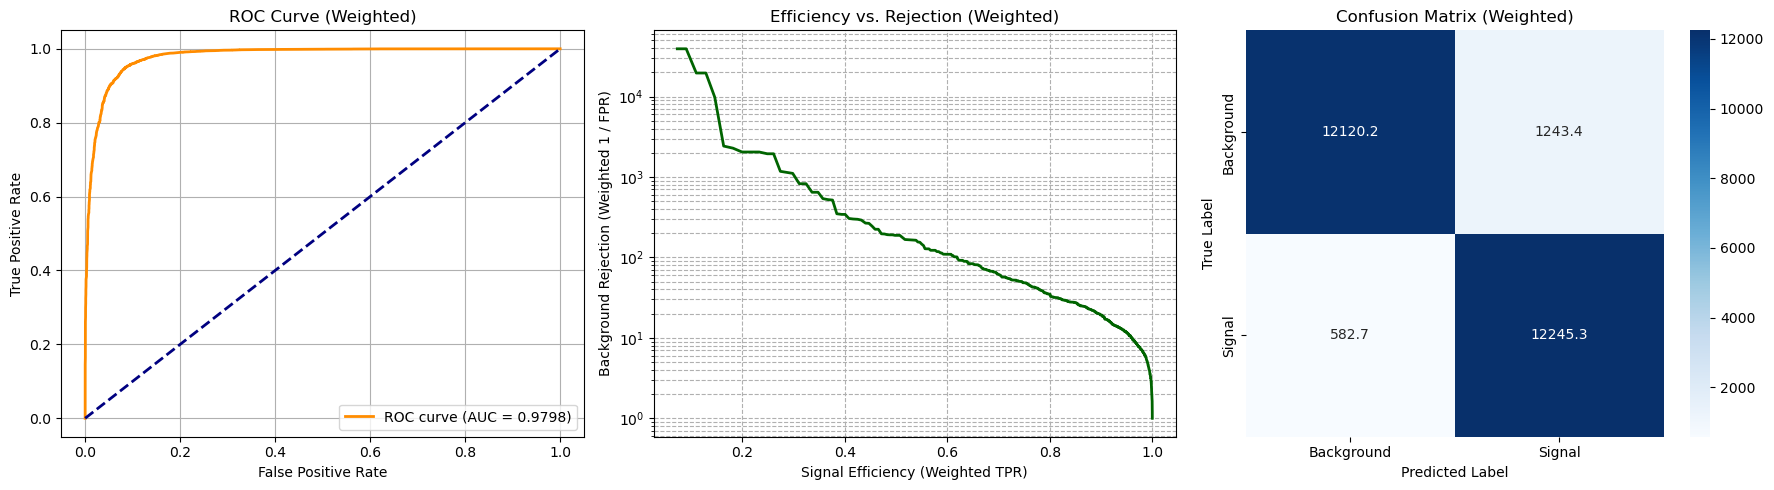

In [37]:
# ==========================================
# 4. Evaluation Function
# ==========================================
def evaluate_combined_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()
    all_labels = []
    all_probas = []
    all_weights = []

    with torch.no_grad():
        for xg, xd, labels, weights in data_loader:
            xg = xg.to(device)
            xd = xd.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(xg, xd)
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy())

    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten()

    # 1. Performance Statistics
    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET (with event weights)\n" + "="*60)
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    # 2. ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Weighted)')
    plt.legend(loc="lower right")
    plt.grid(True)

    # 3. Efficiency vs Rejection
    with np.errstate(divide='ignore'):
        background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
        
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log')
    plt.xlabel('Signal Efficiency (Weighted TPR)')
    plt.ylabel('Background Rejection (Weighted 1 / FPR)')
    plt.title('Efficiency vs. Rejection (Weighted)')
    plt.grid(True, which="both", ls="--")

    # 4. Confusion Matrix
    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) 
    plt.title('Confusion Matrix (Weighted)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

# --- Execution ---
print("\nEvaluating best GDNN model on Test Set...")
gdnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gdnn_model.pth"))
evaluate_combined_model(gdnn_model, test_loader, DEVICE)

In [38]:
# ==========================================
# 5. Score Entire Datasets and Save to Parquet
# ==========================================
import os

def score_and_save_gdnn_dataset(df, X_gnn_raw, X_dnn_raw, g_scaler, d_scaler, model, device, output_path, batch_size=BATCH_SIZE):
    """
    Applies the trained GDNN model to the full dataset, adds the scores as a new column,
    and saves the result to a Parquet file.
    """
    print(f"Generating GDNN scores for {len(df)} events...")
    
    # 1a. Scale GNN Features (Preserving 0-padding)
    N, M, F = X_gnn_raw.shape
    X_gnn_flat = X_gnn_raw.reshape(-1, F).copy()
    is_real = ~np.all(X_gnn_flat == 0, axis=1)
    
    if np.any(is_real):
        X_gnn_flat[is_real] = g_scaler.transform(X_gnn_flat[is_real])
    X_gnn_flat[~is_real] = 0.0 
    X_gnn_scaled = X_gnn_flat.reshape(N, M, F)

    gnn_mean = X_gnn_flat.mean(axis = 0)
    gnn_std = X_gnn_flat.std(axis = 0)

    print("\n--- GNN/Transformer Features (Real Tracks Only) ---")
    print(f"Mean across features: {gnn_mean.mean():.6f} (Expected: ~0.0)")
    print(f"Std across features:  {gnn_std.mean():.6f} (Expected: ~1.0)")
    
    # Just to be absolutely sure, let's look at the first few individual features
    print("\nIndividual GNN Feature Stats (First 4 features):")
    for i in range(min(4, F)):
        print(f"  Feature {i}: Mean = {gnn_mean[i]:.6f}, Std = {gnn_std[i]:.6f}")
    
    # 1b. Scale DNN Features
    X_dnn_scaled = d_scaler.transform(X_dnn_raw)
    
    # 2. Create DataLoader
    tensor_ds = TensorDataset(
        torch.tensor(X_gnn_scaled, dtype=torch.float32),
        torch.tensor(X_dnn_scaled, dtype=torch.float32)
    )
    loader = DataLoader(tensor_ds, batch_size=batch_size, shuffle=False)
    
    # 3. Get predictions
    model.eval()
    all_probas = []
    
    with torch.no_grad():
        for xg, xd in loader:
            xg = xg.to(device, non_blocking=True)
            xd = xd.to(device, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                outputs = model(xg, xd)
                probas = torch.sigmoid(outputs)
            all_probas.extend(probas.cpu().numpy())
            
    # 4. Add the scores to a copy of the dataframe
    df_scored = df.copy() 
    df_scored['gdnn_score'] = np.array(all_probas).flatten()
    
    # 5. Save to Parquet
    df_scored.to_parquet(output_path, engine='pyarrow', index=False)
    print(f" -> Saved successfully to: {output_path}")
    
    return df_scored

print("\n" + "="*60 + "\nSCORING AND SAVING FULL DATASETS (GDNN)\n" + "="*60)

# Ensure the model is using the best weights from Early Stopping
gdnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gdnn_model.pth"))

# #Score Signal Dataset
# # Assuming df_sig_dr_1, xg_sig, and xd_sig are in memory from your earlier data processing steps
# df_sig_gdnn_scored = score_and_save_gdnn_dataset(
#     df=df_sig, 
#     X_gnn_raw=xg_sig, 
#     X_dnn_raw=xd_sig,
#     g_scaler=scaler_gnn, 
#     d_scaler=scaler_dnn,
#     model=gdnn_model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_SIG),
#     batch_size=BATCH_SIZE
# )

# # Score Background Dataset
# df_bkg_gdnn_scored = score_and_save_gdnn_dataset(
#     df=df_bkg, 
#     X_gnn_raw=xg_bg, 
#     X_dnn_raw=xd_bg,
#     g_scaler=scaler_gnn, 
#     d_scaler=scaler_dnn,
#     model=gdnn_model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_BKG),
#     batch_size=BATCH_SIZE
# )

# print("\nAll GDNN processing complete.")


SCORING AND SAVING FULL DATASETS (GDNN)


/tmp/ipykernel_2853/4132206148.py:72: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  gdnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_gdnn_model.pth"))


<All keys matched successfully>

In [39]:
df_test_gdnn_scored = score_and_save_gdnn_dataset(
    df=df_test_gnn_scored, 
    X_gnn_raw=xg_test, 
    X_dnn_raw=xd_test,
    g_scaler=scaler_gnn, 
    d_scaler=scaler_dnn,
    model=gdnn_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, "test_df.parquet"),
    batch_size=BATCH_SIZE
)

Generating GDNN scores for 25656 events...

--- GNN/Transformer Features (Real Tracks Only) ---
Mean across features: -0.000394 (Expected: ~0.0)
Std across features:  0.946638 (Expected: ~1.0)

Individual GNN Feature Stats (First 4 features):
  Feature 0: Mean = 0.000119, Std = 0.949045
  Feature 1: Mean = -0.000729, Std = 0.947619
  Feature 2: Mean = -0.001346, Std = 0.945166
  Feature 3: Mean = 0.000381, Std = 0.944724
 -> Saved successfully to: gdnn_combined_results/test_df.parquet


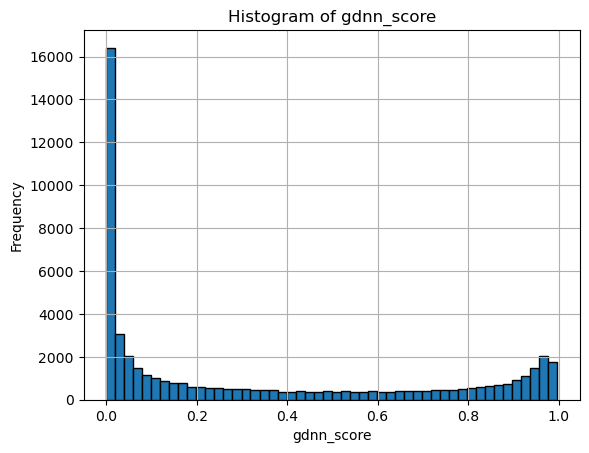

In [187]:
plot_histogram(df_test_gdnn_scored, 'gdnn_score')

In [58]:
# Transformer

In [89]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau # Added LR Scheduler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import os

OUTPUT_DIR = 'transformer_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assume BATCH_SIZE is defined in your global environment (e.g., BATCH_SIZE = 1024)
BATCH_SIZE = 128

# ==========================================
# 1. Data Scaling & DataLoaders
# ==========================================
print("Setting up DataLoaders...")

# Assuming xg_sig, xg_bg, xd_sig, xd_bg, y_sig, y_bg, w_sig, w_bg are available 
# from load_and_process_new_dataset() as mentioned in your setup.
X_gnn_all = np.concatenate([xg_sig, xg_bg], axis=0)
y_all = np.concatenate([y_sig, y_bg], axis=0)
w_all = np.concatenate([w_sig, w_bg], axis=0)

# 1b. Scale GNN/Transformer Features (Masking out zero-padded particles)
N, M, F = X_gnn_all.shape
X_gnn_flat = X_gnn_all.reshape(-1, F)
is_real = ~np.all(X_gnn_flat == 0, axis=1) # Boolean mask for real tracks

scaler_gnn = StandardScaler()
scaler_gnn.fit(X_gnn_flat[is_real])
X_gnn_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
X_gnn_flat[~is_real] = 0.0 # Ensure padding remains exactly zero
X_gnn_all_scaled = X_gnn_flat.reshape(N, M, F)

# 1c. Data Splitting (Train 80% / Val 10% / Test 10%)
print(f"Total Combined dataset size: {len(y_all)} events")
indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

# 1d. Create PyTorch Datasets (Yielding: x_gnn, x_dnn, y, w)
train_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.tensor(y_all[train_idx], dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[train_idx], dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.tensor(y_all[val_idx].copy(), dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[val_idx].copy(), dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.tensor(X_gnn_all_scaled[test_idx].copy(), dtype=torch.float32), 
    torch.tensor(X_dnn_all_scaled[test_idx].copy(), dtype=torch.float32), 
    torch.tensor(y_all[test_idx].copy(), dtype=torch.float32).view(-1, 1), 
    torch.tensor(w_all[test_idx].copy(), dtype=torch.float32).view(-1, 1)
)

# num_workers=0 avoids multiprocessing segfaults for in-memory datasets
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

Setting up DataLoaders...
Total Combined dataset size: 256551 events


In [90]:
import torch
import torch.nn as nn

class ParticleTransformer(nn.Module):
    def __init__(self, n_features, d_model=256, nhead=8, num_layers=5, dim_feedforward=512, dropout=0.1):
        super(ParticleTransformer, self).__init__()
        
        self.embedding = nn.Linear(n_features, d_model)
        self.norm_in = nn.LayerNorm(d_model)
        
        # Initialize CLS token as a learnable parameter
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        nn.init.trunc_normal_(self.cls_token, std=0.02)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, 
            dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.cls_head = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, 128),
            nn.GELU(),
            nn.Dropout(0.05),
            nn.Linear(128, 128),
            nn.GELU(),
            nn.Linear(128, 64),
            nn.GELU(),
            nn.Linear(64, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x, mask=None):
        # x shape: [batch, n_particles, n_features]
        batch_size = x.size(0)
        
        # 1. Embed and Norm
        x = self.embedding(x)
        x = self.norm_in(x)
        
        cls_tokens = self.cls_token.expand(batch_size, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1) 
        
        if mask is not None:
            cls_mask = torch.zeros((batch_size, 1), dtype=torch.bool, device=x.device)
            mask = torch.cat((cls_mask, mask), dim=1)
        
        x = self.transformer_encoder(x, src_key_padding_mask=mask)
        
        cls_out = x[:, 0, :]
            
        return self.cls_head(cls_out)

class AutoMaskedTransformer(nn.Module):
    def __init__(self, transformer_model):
        super(AutoMaskedTransformer, self).__init__()
        self.model = transformer_model
        
    def forward(self, x):
        # Mask is True where all features are 0 (padding)
        mask = (x == 0).all(dim=-1)
        return self.model(x, mask=mask)

In [91]:
# 1. Initialize the base model
base_transformer = ParticleTransformer(n_features=4) 

# 2. Wrap it (this doesn't change the parameters)
transformer_model = AutoMaskedTransformer(base_transformer).to(DEVICE)

optimizer = optim.AdamW(transformer_model.parameters(), lr=1e-4, weight_decay=1e-4)

# --- ADDED: Initialize the Scheduler ---
# Trigger after 2 epochs of no improvement, halving the learning rate
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

scaler = torch.amp.GradScaler('cuda')

def weighted_bce_loss(output, target, weight):
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    weighted_loss = loss * weight
    # Divide by the sum of weights to get a true weighted average
    return weighted_loss.sum() / (weight.sum() + 1e-8)

In [92]:
# ==========================================
# 3. Training Loop with Early Stopping
# ==========================================
print("\nStarting Transformer Training...")
EPOCHS = 100 
best_val_loss = float('inf')
patience = 12
epochs_no_improve = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- Training ---
    transformer_model.train()
    train_loss = 0
    
    for xg, xd, y_batch, w_batch in train_loader:
        xg = xg.to(DEVICE, non_blocking=True)
        # We ignore xd here since this is a standalone Transformer
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        w_batch = w_batch.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            out = transformer_model(xg)
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * xg.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # --- Validation ---
    transformer_model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for xg, xd, y_batch, w_batch in val_loader:
            xg = xg.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            w_batch = w_batch.to(DEVICE, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                out = transformer_model(xg)
                loss = weighted_bce_loss(out, y_batch, w_batch)
            
            val_loss += loss.item() * xg.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    # --- ADDED: Step the Scheduler ---
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Time: {time.time() - start_time:.1f}s")
    
    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(transformer_model.state_dict(), f"{OUTPUT_DIR}/best_transformer_only.pth")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered! Training stopped at epoch {epoch+1}.")
            break

print("Training Complete!")


Starting Transformer Training...
Epoch [1/100] | Train Loss: 0.6091 | Val Loss: 0.5837 | LR: 0.000100 | Time: 43.5s
Epoch [2/100] | Train Loss: 0.5858 | Val Loss: 0.5713 | LR: 0.000100 | Time: 44.7s
Epoch [3/100] | Train Loss: 0.5780 | Val Loss: 0.5663 | LR: 0.000100 | Time: 43.6s
Epoch [4/100] | Train Loss: 0.5729 | Val Loss: 0.5614 | LR: 0.000100 | Time: 44.4s
Epoch [5/100] | Train Loss: 0.5698 | Val Loss: 0.5593 | LR: 0.000100 | Time: 44.0s
Epoch [6/100] | Train Loss: 0.5671 | Val Loss: 0.5615 | LR: 0.000100 | Time: 44.2s
  -> No improvement for 1 epoch(s).
Epoch [7/100] | Train Loss: 0.5647 | Val Loss: 0.5547 | LR: 0.000100 | Time: 43.4s
Epoch [8/100] | Train Loss: 0.5602 | Val Loss: 0.5568 | LR: 0.000100 | Time: 43.5s
  -> No improvement for 1 epoch(s).
Epoch [9/100] | Train Loss: 0.5583 | Val Loss: 0.5685 | LR: 0.000100 | Time: 43.2s
  -> No improvement for 2 epoch(s).
Epoch [10/100] | Train Loss: 0.5553 | Val Loss: 0.5551 | LR: 0.000100 | Time: 43.4s
  -> No improvement for 3 e

KeyboardInterrupt: 

In [93]:
# ==========================================
# 4. Evaluation Function
# ==========================================
def evaluate_transformer_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()  
    all_labels = []
    all_probas = []
    all_weights = [] 

    with torch.no_grad():
        for xg, xd, labels, weights in data_loader:
            xg = xg.to(device)
            # xd is ignored for Transformer
            
            with torch.amp.autocast('cuda'):
                outputs = model(xg)
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy()) 

    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten() 

    # 1. Performance Statistics 
    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET (with event weights)\n" + "="*60)
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    # 2. ROC Curve 
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Weighted)')
    plt.legend(loc="lower right")
    plt.grid(True)

    # 3. Efficiency vs Rejection 
    with np.errstate(divide='ignore'):
        background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
        
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log')
    plt.xlabel('Signal Efficiency (Weighted TPR)')
    plt.ylabel('Background Rejection (Weighted 1 / FPR)')
    plt.title('Efficiency vs. Rejection (Weighted)')
    plt.grid(True, which="both", ls="--")

    # 4. Confusion Matrix 
    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) 
    plt.title('Confusion Matrix (Weighted)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()



Evaluating best Transformer model on Test Set...


/tmp/ipykernel_2853/2689335155.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  transformer_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_transformer_only.pth"))



FINAL PERFORMANCE ON TEST SET (with event weights)
              precision    recall  f1-score   support

  Background       0.71      0.73      0.72 13363.615883350372
      Signal       0.71      0.69      0.70 12827.991765737534

    accuracy                           0.71 26191.607649087906
   macro avg       0.71      0.71      0.71 26191.607649087906
weighted avg       0.71      0.71      0.71 26191.607649087906



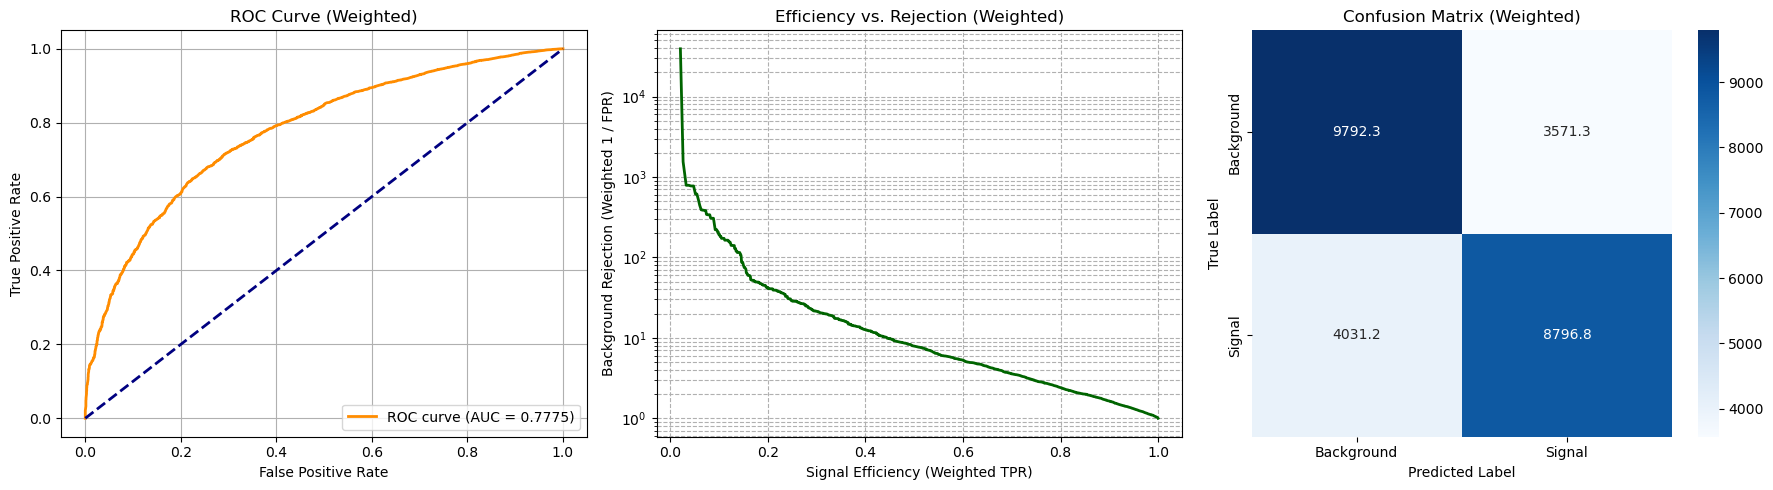

In [94]:
# --- Execution ---
print("\nEvaluating best Transformer model on Test Set...")
transformer_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_transformer_only.pth"))
evaluate_transformer_model(transformer_model, test_loader, DEVICE)

In [45]:
# ==========================================
# 5. Score Entire Datasets and Save to Parquet
# ==========================================
def score_and_save_transformer_dataset(df, X_gnn_raw, scaler, model, device, output_path, batch_size=BATCH_SIZE):
    """
    Applies the trained Transformer model to the full dataset, adds the scores as a new column,
    and saves the result to a Parquet file.
    """
    print(f"Generating Transformer scores for {len(df)} events...")
    
    # 1. Scale GNN Features (Preserving 0-padding)
    N, M, F = X_gnn_raw.shape
    X_gnn_flat = X_gnn_raw.reshape(-1, F).copy()
    is_real = ~np.all(X_gnn_flat == 0, axis=1)
    
    if np.any(is_real):
        X_gnn_flat[is_real] = scaler.transform(X_gnn_flat[is_real])
    X_gnn_flat[~is_real] = 0.0 
    X_gnn_scaled = X_gnn_flat.reshape(N, M, F)

    gnn_flat_check = X_gnn_scaled.reshape(-1, F)
    real_tracks_only = gnn_flat_check[is_real]
    
    gnn_mean = real_tracks_only.mean(axis=0)
    gnn_std = real_tracks_only.std(axis=0)
    
    print("\n--- GNN/Transformer Features (Real Tracks Only) ---")
    print(f"Mean across features: {gnn_mean.mean():.6f} (Expected: ~0.0)")
    print(f"Std across features:  {gnn_std.mean():.6f} (Expected: ~1.0)")
    
    # Just to be absolutely sure, let's look at the first few individual features
    print("\nIndividual GNN Feature Stats (First 4 features):")
    for i in range(min(4, F)):
        print(f"  Feature {i}: Mean = {gnn_mean[i]:.6f}, Std = {gnn_std[i]:.6f}")
    
    # 2. Create DataLoader (Only GNN needed for Transformer)
    tensor_ds = TensorDataset(
        torch.tensor(X_gnn_scaled, dtype=torch.float32)
    )
    loader = DataLoader(tensor_ds, batch_size=batch_size, shuffle=False)
    
    # 3. Get predictions
    model.eval()
    all_probas = []
    
    with torch.no_grad():
        for xg_batch in loader:
            # DataLoader returns a tuple of length 1, extract the tensor
            xg = xg_batch[0].to(device, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                
                outputs = model(xg)
                probas = torch.sigmoid(outputs)
            all_probas.extend(probas.cpu().numpy())
            
    # 4. Add the scores to a copy of the dataframe
    df_scored = df.copy() 
    df_scored['t_score'] = np.array(all_probas).flatten()
    
    # 5. Save to Parquet
    df_scored.to_parquet(output_path, engine='pyarrow', index=False)
    print(f" -> Saved successfully to: {output_path}")
    
    return df_scored

print("\n" + "="*60 + "\nSCORING AND SAVING FULL DATASETS (TRANSFORMER)\n" + "="*60)

# Ensure the model is using the best weights from Early Stopping
transformer_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_transformer_only.pth"))

# Score Signal Dataset
# Assuming df_sig is your original signal dataframe from the setup step
# df_sig_t_scored = score_and_save_transformer_dataset(
#     df=df_sig, 
#     X_gnn_raw=xg_sig, 
#     scaler=scaler_gnn, 
#     model=transformer_model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_SIG),
#     batch_size=BATCH_SIZE
# )

# # Score Background Dataset
# # Assuming df_bkg is your original background dataframe from the setup step
# df_bkg_t_scored = score_and_save_transformer_dataset(
#     df=df_bkg, 
#     X_gnn_raw=xg_bg, 
#     scaler=scaler_gnn, 
#     model=transformer_model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_BKG),
#     batch_size=BATCH_SIZE
# )

# print("\nAll Transformer processing complete.")


SCORING AND SAVING FULL DATASETS (TRANSFORMER)


/tmp/ipykernel_2853/2923059133.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  transformer_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_transformer_only.pth"))


<All keys matched successfully>

In [46]:
df_test_t_scored = score_and_save_transformer_dataset(
    df=df_test_gdnn_scored, 
    X_gnn_raw=xg_test, 
    scaler=scaler_gnn, 
    model=transformer_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, "test_df.parquet"),
    batch_size=BATCH_SIZE
)

Generating Transformer scores for 25656 events...

--- GNN/Transformer Features (Real Tracks Only) ---
Mean across features: -0.000439 (Expected: ~0.0)
Std across features:  0.999417 (Expected: ~1.0)

Individual GNN Feature Stats (First 4 features):
  Feature 0: Mean = 0.000132, Std = 1.001958
  Feature 1: Mean = -0.000812, Std = 1.000453
  Feature 2: Mean = -0.001500, Std = 0.997862
  Feature 3: Mean = 0.000425, Std = 0.997394
 -> Saved successfully to: transformer_results/test_df.parquet


In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau # Added LR Scheduler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import os

OUTPUT_DIR = 'tdnn_combined_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128


print("Scaling Data and Setting up DataLoaders...")

# Concatenate Labels and Weights
X_gnn_all = np.concatenate([xg_sig, xg_bg], axis=0)
X_dnn_all = np.concatenate([xd_sig, xd_bg], axis=0)
y_all = np.concatenate([y_sig, y_bg], axis=0)
w_all = np.concatenate([w_sig, w_bg], axis=0)

# 1a. Scale DNN Features
scaler_dnn = StandardScaler()
X_dnn_all_scaled = scaler_dnn.fit_transform(X_dnn_all)

# 1b. Scale GNN/Transformer Features (Masking out zero-padded particles)
N, M, F = X_gnn_all.shape
X_gnn_flat = X_gnn_all.reshape(-1, F)
is_real = ~np.all(X_gnn_flat == 0, axis=1) # Boolean mask for real tracks

scaler_gnn = StandardScaler()
scaler_gnn.fit(X_gnn_flat[is_real])
X_gnn_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
X_gnn_flat[~is_real] = 0.0 # Ensure padding remains exactly zero
X_gnn_all_scaled = X_gnn_flat.reshape(N, M, F)

gnn_mean = X_gnn_flat.mean(axis=0)
gnn_std = X_gnn_flat.std(axis=0)

print("\n--- GNN/Transformer Features (Real Tracks Only) ---")
print(f"Mean across features: {gnn_mean.mean():.6f} (Expected: ~0.0)")
print(f"Std across features:  {gnn_std.mean():.6f} (Expected: ~1.0)")

# Just to be absolutely sure, let's look at the first few individual features
print("\nIndividual GNN Feature Stats (First 4 features):")
for i in range(min(4, F)):
    print(f"  Feature {i}: Mean = {gnn_mean[i]:.6f}, Std = {gnn_std[i]:.6f}")

# 1c. Data Splitting (Train 80% / Val 10% / Test 10%)
print(f"Total Combined dataset size: {len(y_all)} events")
indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

# 1d. Create PyTorch Datasets 
train_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.as_tensor(X_dnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[train_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[train_idx], dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.as_tensor(X_dnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[val_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[val_idx], dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.as_tensor(X_dnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[test_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[test_idx], dtype=torch.float32).view(-1, 1)
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)

Scaling Data and Setting up DataLoaders...

--- GNN/Transformer Features (Real Tracks Only) ---
Mean across features: 0.000000 (Expected: ~0.0)
Std across features:  0.942369 (Expected: ~1.0)

Individual GNN Feature Stats (First 4 features):
  Feature 0: Mean = 0.000000, Std = 0.942635
  Feature 1: Mean = -0.000000, Std = 0.941555
  Feature 2: Mean = 0.000000, Std = 0.941361
  Feature 3: Mean = 0.000001, Std = 0.943923
Total Combined dataset size: 256551 events


In [48]:
# ==========================================
# 2. Model Definition (TDNN)
# ==========================================
class ParticleTransformerExtractor(nn.Module):
    def __init__(self, n_features, d_model=128, nhead=8, num_layers=5, dim_feedforward=512, dropout=0.1, output_latent_dim=24):
        super(ParticleTransformerExtractor, self).__init__()
        
        self.embedding = nn.Linear(n_features, d_model)
        self.norm_in = nn.LayerNorm(d_model)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward, 
            dropout=dropout, batch_first=True, activation='gelu'
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.latent_proj = nn.Sequential(
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(128, 128),
            nn.GELU(),

            nn.Linear(128, 64),
            nn.GELU(),

            nn.Linear(64, output_latent_dim),
            nn.ReLU(),
        )

    def forward(self, x, mask=None):
        x = self.embedding(x)
        x = self.norm_in(x)
        x = self.transformer_encoder(x, src_key_padding_mask=mask) 
        
        if mask is not None:
            mask_float = (~mask).float().unsqueeze(-1) 
            x = x * mask_float 
            sum_embeddings = torch.sum(x, dim=1)
            count_valid = torch.sum(mask_float, dim=1)
            pooled = sum_embeddings / (count_valid + 1e-6)
        else:
            pooled = torch.mean(x, dim=1)
            
        return self.latent_proj(pooled)

class AutoMaskedTransformerExtractor(nn.Module):
    def __init__(self, transformer_extractor):
        super(AutoMaskedTransformerExtractor, self).__init__()
        self.model = transformer_extractor
        
    def forward(self, x):
        # A particle is padding if all its features are exactly 0.0
        mask = (x == 0).all(dim=-1)
        return self.model(x, mask=mask)

class DNNBlock(nn.Module):
    def __init__(self, input_dim):
        super(DNNBlock, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.15),
            nn.Linear(128, 128), nn.ReLU(), nn.BatchNorm1d(128), nn.Dropout(0.15),
            nn.Linear(128, 64), nn.ReLU(), nn.BatchNorm1d(64), nn.Dropout(0.15),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

class TDNN(nn.Module):
    def __init__(self, n_transformer_features, n_dnn_features, transformer_latent_dim=24):
        super(TDNN, self).__init__()
        
        base_transformer = ParticleTransformerExtractor(
            n_features=n_transformer_features, 
            output_latent_dim=transformer_latent_dim
        )
        self.transformer_branch = AutoMaskedTransformerExtractor(base_transformer)
        
        combined_dim = transformer_latent_dim + n_dnn_features
        self.dnn_branch = DNNBlock(combined_dim)
        
    def forward(self, x_trans, x_dnn):
        trans_embedding = self.transformer_branch(x_trans)
        combined_features = torch.cat([trans_embedding, x_dnn], dim=1)
        return self.dnn_branch(combined_features)


# ==========================================
# 3. Model Initialization
# ==========================================
transformer_feats = X_gnn_all_scaled.shape[2] 
dnn_feats = X_dnn_all_scaled.shape[1]         

tdnn_model = TDNN(
    n_transformer_features=transformer_feats, 
    n_dnn_features=dnn_feats, 
    transformer_latent_dim=24
).to(DEVICE)

# --- FIX: Using AdamW and lowered LR for Transformer stability ---
optimizer = optim.AdamW(tdnn_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
scaler = torch.amp.GradScaler('cuda')

# --- FIX: Correct weighted loss math so gradients don't vanish ---
def weighted_bce_loss(output, target, weight):
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    weighted_loss = loss * weight
    return weighted_loss.sum() / (weight.sum() + 1e-8)

In [49]:
# ==========================================
# 4. Training Loop
# ==========================================
print("\nStarting Combined TDNN Training...")
EPOCHS = 100 
best_val_loss = float('inf')
patience = 12
epochs_no_improve = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- Training ---
    tdnn_model.train()
    train_loss = 0
    
    for x_trans, x_dnn, y_batch, w_batch in train_loader:
        x_trans = x_trans.to(DEVICE, non_blocking=True)
        x_dnn = x_dnn.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        w_batch = w_batch.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            out = tdnn_model(x_trans, x_dnn)
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * x_trans.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # --- Validation ---
    tdnn_model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for x_trans, x_dnn, y_batch, w_batch in val_loader:
            x_trans = x_trans.to(DEVICE, non_blocking=True)
            x_dnn = x_dnn.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            w_batch = w_batch.to(DEVICE, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                out = tdnn_model(x_trans, x_dnn)
                loss = weighted_bce_loss(out, y_batch, w_batch)
            
            val_loss += loss.item() * x_trans.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Time: {time.time() - start_time:.1f}s")
    
    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(tdnn_model.state_dict(), f"{OUTPUT_DIR}/best_tdnn_model.pth")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered! Training stopped.")
            break

print("Training Complete!")


# ==========================================
# 5. Evaluation 
# ==========================================
def evaluate_combined_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()  
    all_labels, all_probas, all_weights = [], [], [] 

    with torch.no_grad():
        for x_trans, x_dnn, labels, weights in data_loader:
            x_trans = x_trans.to(device)
            x_dnn = x_dnn.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(x_trans, x_dnn)
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy()) 

    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten() 

    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET\n" + "="*60)
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve (Weighted)'); plt.legend(loc="lower right"); plt.grid(True)

    with np.errstate(divide='ignore'):
        background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
    
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log'); plt.xlabel('Signal Efficiency'); plt.ylabel('Background Rejection'); plt.title('Efficiency vs. Rejection'); plt.grid(True, which="both", ls="--")

    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) 
    plt.title('Confusion Matrix (Weighted)'); plt.ylabel('True Label'); plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

print("\nEvaluating best TDNN model on Test Set...")



Starting Combined TDNN Training...
Epoch [1/100] | Train Loss: 0.3098 | Val Loss: 0.2229 | LR: 0.001000 | Time: 35.7s
Epoch [2/100] | Train Loss: 0.2451 | Val Loss: 0.2053 | LR: 0.001000 | Time: 35.4s
Epoch [3/100] | Train Loss: 0.2312 | Val Loss: 0.2037 | LR: 0.001000 | Time: 35.9s
Epoch [4/100] | Train Loss: 0.2257 | Val Loss: 0.2039 | LR: 0.001000 | Time: 37.2s
  -> No improvement for 1 epoch(s).
Epoch [5/100] | Train Loss: 0.2220 | Val Loss: 0.1965 | LR: 0.001000 | Time: 36.7s
Epoch [6/100] | Train Loss: 0.2174 | Val Loss: 0.1940 | LR: 0.001000 | Time: 35.5s
Epoch [7/100] | Train Loss: 0.2142 | Val Loss: 0.1934 | LR: 0.001000 | Time: 36.4s
Epoch [8/100] | Train Loss: 0.2133 | Val Loss: 0.1923 | LR: 0.001000 | Time: 35.4s
Epoch [9/100] | Train Loss: 0.2132 | Val Loss: 0.1922 | LR: 0.001000 | Time: 37.5s
Epoch [10/100] | Train Loss: 0.2100 | Val Loss: 0.1904 | LR: 0.001000 | Time: 35.7s
Epoch [11/100] | Train Loss: 0.2085 | Val Loss: 0.1924 | LR: 0.001000 | Time: 35.2s
  -> No impro

/tmp/ipykernel_2853/3416928134.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tdnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_tdnn_model.pth"))



FINAL PERFORMANCE ON TEST SET
              precision    recall  f1-score   support

  Background       0.95      0.91      0.93 13363.615883350372
      Signal       0.91      0.95      0.93 12827.991765737534

    accuracy                           0.93 26191.607649087906
   macro avg       0.93      0.93      0.93 26191.607649087906
weighted avg       0.93      0.93      0.93 26191.607649087906



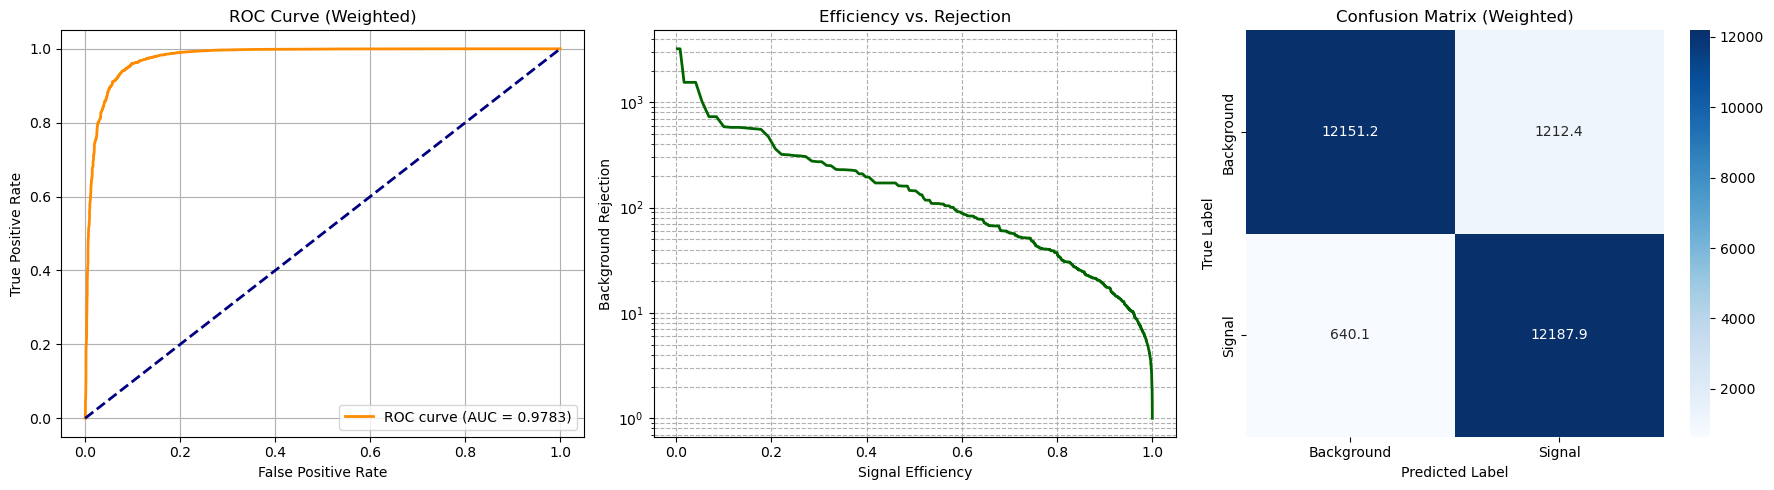

In [50]:
tdnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_tdnn_model.pth"))
evaluate_combined_model(tdnn_model, test_loader, DEVICE)

In [51]:
# ==========================================
# 6. Score Entire Datasets and Save to Parquet
# ==========================================
def score_and_save_tdnn_dataset(df, X_gnn_raw, X_dnn_raw, g_scaler, d_scaler, model, device, output_path, batch_size=BATCH_SIZE):
    print(f"Generating TDNN scores for {len(df)} events...")
    
    # --- FIX: Removed memory duplication (.copy()) ---
    N, M, F = X_gnn_raw.shape
    X_gnn_flat = X_gnn_raw.reshape(-1, F).copy()
    is_real = ~np.all(X_gnn_flat == 0, axis=1)
    
    # Create an empty array to hold the scaled features
    X_gnn_scaled_flat = np.zeros_like(X_gnn_flat)
    if np.any(is_real):
        X_gnn_scaled_flat[is_real] = g_scaler.transform(X_gnn_flat[is_real])
        print("scaling")
        
    X_gnn_scaled = X_gnn_scaled_flat.reshape(N, M, F)

    gnn_mean = X_gnn_scaled_flat.mean(axis=0)
    gnn_std = X_gnn_scaled_flat.std(axis=0)
    
    print("\n--- GNN/Transformer Features (Real Tracks Only) ---")
    print(f"Mean across features: {gnn_mean.mean():.6f} (Expected: ~0.0)")
    print(f"Std across features:  {gnn_std.mean():.6f} (Expected: ~1.0)")
    
    # Just to be absolutely sure, let's look at the first few individual features
    print("\nIndividual GNN Feature Stats (First 4 features):")
    for i in range(min(4, F)):
        print(f"  Feature {i}: Mean = {gnn_mean[i]:.6f}, Std = {gnn_std[i]:.6f}")

    
    X_dnn_scaled = d_scaler.transform(X_dnn_raw)
    
    
    tensor_ds = TensorDataset(
        torch.as_tensor(X_gnn_scaled, dtype=torch.float32),
        torch.as_tensor(X_dnn_scaled, dtype=torch.float32)
    )
    loader = DataLoader(tensor_ds, batch_size=batch_size, shuffle=False)
    
    model.eval()
    all_probas = []
    
    with torch.no_grad():
        for xg, xd in loader:
            xg = xg.to(device, non_blocking=True)
            xd = xd.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                outputs = model(xg, xd)
                probas = torch.sigmoid(outputs)
            all_probas.extend(probas.cpu().numpy())
            
    df_scored = df.copy() 
    df_scored['tdnn_score'] = np.array(all_probas).flatten()
    df_scored.to_parquet(output_path, engine='pyarrow', index=False)
    print(f" -> Saved successfully to: {output_path}")
    return df_scored

print("\n" + "="*60 + "\nSCORING AND SAVING FULL DATASETS (TDNN)\n" + "="*60)

# df_sig_tdnn_scored = score_and_save_tdnn_dataset(
#     df=df_sig_t_scored,
#     X_gnn_raw=xg_sig,
#     X_dnn_raw=xd_sig,
#     g_scaler=scaler_gnn,
#     d_scaler=scaler_dnn,
#     model=tdnn_model,
#     device=DEVICE,
#     output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_SIG)
# )

# df_bkg_tdnn_scored = score_and_save_tdnn_dataset(
#     df=df_bkg_t_scored,
#     X_gnn_raw=xg_bg,
#     X_dnn_raw=xd_bg,
#     g_scaler=scaler_gnn,
#     d_scaler=scaler_dnn,
#     model=tdnn_model,
#     device=DEVICE,
#     output_path=os.path.join(OUTPUT_DIR, SCORED_PARQUET_BKG)
# )

# print("\nAll TDNN processing complete.")


SCORING AND SAVING FULL DATASETS (TDNN)


In [52]:
tdnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_tdnn_model.pth"))

df_test_tdnn_scored = score_and_save_tdnn_dataset(
    df=df_test_t_scored,
    X_gnn_raw=xg_test,
    X_dnn_raw=xd_test,
    g_scaler=scaler_gnn,
    d_scaler=scaler_dnn,
    model=tdnn_model,
    device=DEVICE,
    output_path=os.path.join(OUTPUT_DIR, "test_df.parquet")
)

/tmp/ipykernel_2853/1131583144.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tdnn_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_tdnn_model.pth"))


Generating TDNN scores for 25656 events...
scaling

--- GNN/Transformer Features (Real Tracks Only) ---
Mean across features: -0.000394 (Expected: ~0.0)
Std across features:  0.946638 (Expected: ~1.0)

Individual GNN Feature Stats (First 4 features):
  Feature 0: Mean = 0.000119, Std = 0.949045
  Feature 1: Mean = -0.000729, Std = 0.947619
  Feature 2: Mean = -0.001346, Std = 0.945166
  Feature 3: Mean = 0.000381, Std = 0.944724
 -> Saved successfully to: tdnn_combined_results/test_df.parquet


In [ ]:
#Particle Net

In [220]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import os

OUTPUT_DIR = 'particlenet_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reduced batch size slightly compared to Transformer, as EdgeConv uses more VRAM
BATCH_SIZE = 64

# ==========================================
# 1. Data Scaling & DataLoaders
# ==========================================
print("Setting up DataLoaders...")

# Assuming xg_sig, xg_bg, xd_sig, xd_bg, y_sig, y_bg, w_sig, w_bg are available 
# from load_and_process_new_dataset() as mentioned in your setup.

X_gnn_all = np.concatenate([xg_sig, xg_bg], axis=0)
X_dnn_all = np.concatenate([xd_sig, xd_bg], axis=0)
y_all = np.concatenate([y_sig, y_bg], axis=0)

w_all = np.concatenate([w_sig, w_bg], axis=0)

# 1a. Scale DNN Features (Included for dataset alignment, even if unused by the model)
scaler_dnn = StandardScaler()
X_dnn_all_scaled = scaler_dnn.fit_transform(X_dnn_all)

# 1b. Scale GNN/ParticleNet Features (Masking out zero-padded particles)
N, M, F = X_gnn_all.shape
X_gnn_flat = X_gnn_all.reshape(-1, F)
is_real = ~np.all(X_gnn_flat == 0, axis=1) # Boolean mask for real tracks

scaler_gnn = StandardScaler()
scaler_gnn.fit(X_gnn_flat[is_real])
X_gnn_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
X_gnn_flat[~is_real] = 0.0 # Ensure padding remains exactly zero
X_gnn_all_scaled = X_gnn_flat.reshape(N, M, F)

# 1c. Data Splitting (Train 80% / Val 10% / Test 10%)
print(f"Total Combined dataset size: {len(y_all)} events")
indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

# 1d. Create PyTorch Datasets (Using memory-safe torch.as_tensor instead of .copy())
train_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.as_tensor(X_dnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[train_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[train_idx], dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.as_tensor(X_dnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[val_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[val_idx], dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.as_tensor(X_dnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[test_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[test_idx], dtype=torch.float32).view(-1, 1)
)

# drop_last=True prevents BatchNorm crashing on final odd-sized batch
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)


# ==========================================
# 2. Model Definition (ParticleNet)
# ==========================================
def knn(x, k, mask=None):
    if mask is not None:
        offset = mask.float().unsqueeze(1) * 1e5
        x_dist = x + offset
    else:
        x_dist = x
    inner = -2 * torch.matmul(x_dist.transpose(2, 1), x_dist)
    xx = torch.sum(x_dist**2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    idx = pairwise_distance.topk(k=k, dim=-1)[1]
    return idx

def get_graph_feature(x, k, idx):
    batch_size = x.size(0)
    num_points = x.size(2)
    x = x.view(batch_size, -1, num_points)
    device = x.device

    idx_base = torch.arange(0, batch_size, device=device).view(-1, 1, 1) * num_points
    idx = idx + idx_base
    idx = idx.view(-1)

    _, num_dims, _ = x.size()
    x = x.transpose(2, 1).contiguous()
    feature = x.view(batch_size * num_points, -1)[idx, :]
    feature = feature.view(batch_size, num_points, k, num_dims)
    x = x.view(batch_size, num_points, 1, num_dims).repeat(1, 1, k, 1)
    
    feature = torch.cat((feature - x, x), dim=3).permute(0, 3, 1, 2).contiguous()
    return feature

class EdgeConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels_list, k=16):
        super(EdgeConvBlock, self).__init__()
        self.k = k
        self.convs = nn.ModuleList()
        in_c = in_channels * 2
        
        for out_c in out_channels_list:
            self.convs.append(
                nn.Sequential(
                    nn.Conv2d(in_c, out_c, kernel_size=1, bias=False),
                    nn.BatchNorm2d(out_c),
                    nn.LeakyReLU(negative_slope=0.2)
                )
            )
            in_c = out_c

    def forward(self, x, mask=None):
        idx = knn(x, k=self.k, mask=mask)
        x_edges = get_graph_feature(x, self.k, idx)
        
        for conv in self.convs:
            x_edges = conv(x_edges)
            
        x_out = x_edges.max(dim=-1, keepdim=False)[0]
        if mask is not None:
            x_out = x_out * (~mask).float().unsqueeze(1)
        return x_out

class ParticleNet(nn.Module):
    def __init__(self, n_features, k=16):
        super(ParticleNet, self).__init__()
        self.k = k
        
        self.edge_conv1 = EdgeConvBlock(n_features, [64, 64], k=k)
        self.edge_conv2 = EdgeConvBlock(64, [128, 128], k=k)
        self.edge_conv3 = EdgeConvBlock(128, [256, 256], k=k)
        
        # Classifier Head (Standalone Model)
        self.cls_head = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            
            nn.Linear(64, 1) # Logits
        )

    def forward(self, x, mask=None):
        x = x.transpose(1, 2).contiguous() # [B, Features, N_particles]
        
        x = self.edge_conv1(x, mask=mask)
        x = self.edge_conv2(x, mask=mask)
        x = self.edge_conv3(x, mask=mask)
        
        if mask is not None:
            sum_embeddings = torch.sum(x, dim=2)
            count_valid = torch.sum((~mask).float(), dim=1, keepdim=True)
            pooled = sum_embeddings / (count_valid + 1e-6)
        else:
            pooled = torch.mean(x, dim=2)
            
        return self.cls_head(pooled)

class AutoMaskedParticleNet(nn.Module):
    def __init__(self, pnet_model):
        super(AutoMaskedParticleNet, self).__init__()
        self.model = pnet_model
        
    def forward(self, x):
        mask = (x == 0).all(dim=-1)
        return self.model(x, mask=mask)

# Initialize Model
base_pnet = ParticleNet(n_features=X_gnn_all_scaled.shape[2], k=16)
pnet_model = AutoMaskedParticleNet(base_pnet).to(DEVICE)

# CNNs handle learning rates much better than Transformers. 1e-3 is safe.
optimizer = optim.AdamW(pnet_model.parameters(), lr=1e-3, weight_decay=1e-4)

# Trigger after 3 epochs of no improvement, halving the learning rate
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)

scaler = torch.amp.GradScaler('cuda')

def weighted_bce_loss(output, target, weight):
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    weighted_loss = loss * weight
    return weighted_loss.sum() / (weight.sum() + 1e-8)

Setting up DataLoaders...
Total Combined dataset size: 511731 events


In [ ]:
# ==========================================
# 3. Training Loop with Early Stopping
# ==========================================
print("\nStarting ParticleNet Training...")
EPOCHS = 100 
best_val_loss = float('inf')
patience = 12
epochs_no_improve = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    
    # --- Training ---
    pnet_model.train()
    train_loss = 0
    
    for xg, xd, y_batch, w_batch in train_loader:
        xg = xg.to(DEVICE, non_blocking=True)
        # We ignore xd here since this is a standalone ParticleNet
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        w_batch = w_batch.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            out = pnet_model(xg)
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * xg.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # --- Validation ---
    pnet_model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for xg, xd, y_batch, w_batch in val_loader:
            xg = xg.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            w_batch = w_batch.to(DEVICE, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                out = pnet_model(xg)
                loss = weighted_bce_loss(out, y_batch, w_batch)
            
            val_loss += loss.item() * xg.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    # --- Step the Scheduler ---
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Time: {time.time() - start_time:.1f}s")
    
    # --- Early Stopping ---
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(pnet_model.state_dict(), f"{OUTPUT_DIR}/best_pnet_only.pth")
    else:
        epochs_no_improve += 1
        print(f"  -> No improvement for {epochs_no_improve} epoch(s).")
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered! Training stopped at epoch {epoch+1}.")
            break

print("Training Complete!")

In [ ]:
# ==========================================
# 4. Evaluation Function
# ==========================================
def evaluate_pnet_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()  
    all_labels = []
    all_probas = []
    all_weights = [] 

    with torch.no_grad():
        for xg, xd, labels, weights in data_loader:
            xg = xg.to(device)
            # xd is ignored for standalone ParticleNet
            
            with torch.amp.autocast('cuda'):
                outputs = model(xg)
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy()) 

    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten() 

    # 1. Performance Statistics 
    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET (with event weights)\n" + "="*60)
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    # 2. ROC Curve 
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve (Weighted)')
    plt.legend(loc="lower right")
    plt.grid(True)

    # 3. Efficiency vs Rejection 
    with np.errstate(divide='ignore'):
        background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
        
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log')
    plt.xlabel('Signal Efficiency (Weighted TPR)')
    plt.ylabel('Background Rejection (Weighted 1 / FPR)')
    plt.title('Efficiency vs. Rejection (Weighted)')
    plt.grid(True, which="both", ls="--")

    # 4. Confusion Matrix 
    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) 
    plt.title('Confusion Matrix (Weighted)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

# --- Execution ---
print("\nEvaluating best ParticleNet model on Test Set...")
pnet_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_pnet_only.pth"))
evaluate_pnet_model(pnet_model, test_loader, DEVICE)

In [221]:
# ==========================================
# 5. Score Entire Datasets and Save to Parquet
# ==========================================
def score_and_save_pnet_dataset(df, X_gnn_raw, scaler_gnn, model, device, output_path, batch_size=BATCH_SIZE):
    """
    Applies the trained ParticleNet model to the full dataset, adds the scores as a new column,
    and saves the result to a Parquet file.
    """
    print(f"Generating ParticleNet scores for {len(df)} events...")
    
    # 1. Scale GNN Features (Preserving 0-padding, avoiding memory duplication)
    N, M, F = X_gnn_raw.shape
    X_gnn_flat = X_gnn_raw.reshape(-1, F)
    is_real = ~np.all(X_gnn_flat == 0, axis=1)
    
    X_gnn_scaled_flat = np.zeros_like(X_gnn_flat)
    if np.any(is_real):
        X_gnn_scaled_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
        
    X_gnn_scaled = X_gnn_scaled_flat.reshape(N, M, F)
    
    # 2. Create DataLoader (Only GNN needed for ParticleNet)
    tensor_ds = TensorDataset(
        torch.as_tensor(X_gnn_scaled, dtype=torch.float32)
    )
    loader = DataLoader(tensor_ds, batch_size=batch_size, shuffle=False)
    
    # 3. Get predictions
    model.eval()
    all_probas = []
    
    with torch.no_grad():
        for xg_batch in loader:
            xg = xg_batch[0].to(device, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                outputs = model(xg)
                probas = torch.sigmoid(outputs)
            all_probas.extend(probas.cpu().numpy())
            
    # 4. Add the scores to a copy of the dataframe
    df_scored = df.copy() 
    df_scored['pnet_score'] = np.array(all_probas).flatten()
    
    # 5. Save to Parquet
    df_scored.to_parquet(output_path, engine='pyarrow', index=False)
    print(f" -> Saved successfully to: {output_path}")
    
    return df_scored

print("\n" + "="*60 + "\nSCORING AND SAVING FULL DATASETS (PARTICLENET)\n" + "="*60)

# Ensure the model is using the best weights from Early Stopping
pnet_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_pnet_only.pth"))

# Score Signal Dataset
# df_sig_pnet_scored = score_and_save_pnet_dataset(
#     df=df_sig, # Assumes df_sig is your loaded pandas dataframe
#     X_gnn_raw=xg_sig, 
#     scaler_gnn=scaler_gnn, 
#     model=pnet_model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, 'signal_pnet_scored.parquet'),
#     batch_size=BATCH_SIZE
# )

# # Score Background Dataset
# df_bkg_pnet_scored = score_and_save_pnet_dataset(
#     df=df_bkg, # Assumes df_bkg is your loaded pandas dataframe
#     X_gnn_raw=xg_bg, 
#     scaler_gnn=scaler_gnn, 
#     model=pnet_model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, 'background_pnet_scored.parquet'),
#     batch_size=BATCH_SIZE
# )

print("\nAll ParticleNet processing complete.")


SCORING AND SAVING FULL DATASETS (PARTICLENET)

All ParticleNet processing complete.


/tmp/ipykernel_166/2835126631.py:54: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pnet_model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_pnet_only.pth"))


In [222]:
df_test_pnet_scored = score_and_save_pnet_dataset(
    df=df_test_tdnn_scored,
    X_gnn_raw=xg_test, 
    scaler_gnn=scaler_gnn, 
    model=pnet_model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, 'test_df.parquet'),
    batch_size=BATCH_SIZE
)


Generating ParticleNet scores for 51174 events...
 -> Saved successfully to: particlenet_results/test_df.parquet


In [ ]:
# particleNet (dynamic knn)

In [223]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import os

OUTPUT_DIR = 'multiscale_pnet_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Batch size kept to 64 to avoid VRAM Out-Of-Memory due to massive k-NN distance matrices
BATCH_SIZE = 64

# ==========================================
# 1. Data Scaling & DataLoaders
# ==========================================
print("Setting up DataLoaders...")

# Assuming xg_sig, xg_bg, xd_sig, xd_bg, y_sig, y_bg, w_sig, w_bg are available.
# X_gnn_all features: [relative_pt, deta, dphi, dr]

X_gnn_all = np.concatenate([xg_sig, xg_bg], axis=0)
X_dnn_all = np.concatenate([xd_sig, xd_bg], axis=0)
y_all = np.concatenate([y_sig, y_bg], axis=0)

# FIX: Protect against negative physics event weights
w_all = np.abs(np.concatenate([w_sig, w_bg], axis=0))

# 1a. Scale DNN Features
scaler_dnn = StandardScaler()
X_dnn_all_scaled = scaler_dnn.fit_transform(X_dnn_all)

# 1b. Scale GNN Features (Masking out zero-padded particles)
N, M, F = X_gnn_all.shape
X_gnn_flat = X_gnn_all.reshape(-1, F)
is_real = ~np.all(X_gnn_flat == 0, axis=1) # Boolean mask for real tracks

scaler_gnn = StandardScaler()
scaler_gnn.fit(X_gnn_flat[is_real])
X_gnn_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
X_gnn_flat[~is_real] = 0.0 # Ensure padding remains exactly zero
X_gnn_all_scaled = X_gnn_flat.reshape(N, M, F)

# 1c. Data Splitting (Train 80% / Val 10% / Test 10%)
print(f"Total Combined dataset size: {len(y_all)} events")
indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

# 1d. Create PyTorch Datasets (Memory safe torch.as_tensor)
train_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.as_tensor(X_dnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[train_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[train_idx], dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.as_tensor(X_dnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[val_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[val_idx], dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.as_tensor(X_dnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[test_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[test_idx], dtype=torch.float32).view(-1, 1)
)

# num_workers=0 and drop_last=True to prevent RAM/BatchNorm crashes
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)


# ==========================================
# 2. Model Definition: Multi-Scale ParticleNet + DNN
# ==========================================
def knn(x, k, mask=None):
    """ Finds k-nearest neighbors in latent space """
    if mask is not None:
        offset = mask.float().unsqueeze(1) * 1e5
        x_dist = x + offset
    else:
        x_dist = x
    inner = -2 * torch.matmul(x_dist.transpose(2, 1), x_dist)
    xx = torch.sum(x_dist**2, dim=1, keepdim=True)
    pairwise_distance = -xx - inner - xx.transpose(2, 1)
    idx = pairwise_distance.topk(k=k, dim=-1)[1]
    return idx

def get_graph_feature(x, k, idx):
    """ Constructs the EdgeConv tensor (x_j - x_i, x_i) """
    batch_size = x.size(0)
    num_points = x.size(2)
    x = x.view(batch_size, -1, num_points)
    device = x.device

    idx_base = torch.arange(0, batch_size, device=device).view(-1, 1, 1) * num_points
    idx = idx + idx_base
    idx = idx.view(-1)

    _, num_dims, _ = x.size()
    x = x.transpose(2, 1).contiguous()
    feature = x.view(batch_size * num_points, -1)[idx, :]
    feature = feature.view(batch_size, num_points, k, num_dims)
    x = x.view(batch_size, num_points, 1, num_dims).repeat(1, 1, k, 1)
    
    feature = torch.cat((feature - x, x), dim=3).permute(0, 3, 1, 2).contiguous()
    return feature

class EdgeConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels_list, k=16):
        super(EdgeConvBlock, self).__init__()
        self.k = k
        self.convs = nn.ModuleList()
        in_c = in_channels * 2
        
        for out_c in out_channels_list:
            self.convs.append(
                nn.Sequential(
                    nn.Conv2d(in_c, out_c, kernel_size=1, bias=False),
                    nn.BatchNorm2d(out_c),
                    nn.LeakyReLU(negative_slope=0.2)
                )
            )
            in_c = out_c

    def forward(self, x, mask=None):
        idx = knn(x, k=self.k, mask=mask)
        x_edges = get_graph_feature(x, self.k, idx)
        for conv in self.convs:
            x_edges = conv(x_edges)
        x_out = x_edges.max(dim=-1, keepdim=False)[0]
        if mask is not None:
            x_out = x_out * (~mask).float().unsqueeze(1)
        return x_out

class MultiScaleEdgeConv(nn.Module):
    """ Learns local cluster physics (k=8) AND global 2-prong physics (k=24) """
    def __init__(self, in_channels, total_out_channels, k_list=[8, 24]):
        super().__init__()
        self.k_list = k_list
        out_per_branch = total_out_channels // 2
        
        self.branch1 = EdgeConvBlock(in_channels, [out_per_branch, out_per_branch], k=k_list[0])
        self.branch2 = EdgeConvBlock(in_channels, [out_per_branch, out_per_branch], k=k_list[1])

    def forward(self, x, mask=None):
        out1 = self.branch1(x, mask=mask)
        out2 = self.branch2(x, mask=mask)
        return torch.cat([out1, out2], dim=1) # Recombines to total_out_channels

class MS_ParticleNetExtractor(nn.Module):
    def __init__(self, n_features, output_latent_dim=24):
        super(MS_ParticleNetExtractor, self).__init__()
        
        # Multi-Scale Layer (Outputs 64 channels total)
        self.layer1 = MultiScaleEdgeConv(n_features, 64, k_list=[8, 24])
        
        # Deep Abstraction Layers
        self.layer2 = EdgeConvBlock(64, [128, 128], k=16)
        self.layer3 = EdgeConvBlock(128, [256, 256], k=16)
        
        # Project down to latent representation
        self.latent_proj = nn.Sequential(
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.1),
            nn.Linear(128, output_latent_dim),
            nn.LeakyReLU(0.2)
        )

    def forward(self, x, mask=None):
        x = x.transpose(1, 2).contiguous() # [B, Features, N_particles]
        
        x = self.layer1(x, mask=mask)
        x = self.layer2(x, mask=mask)
        x = self.layer3(x, mask=mask)
        
        # Mask-aware global pooling
        if mask is not None:
            sum_embeddings = torch.sum(x, dim=2)
            count_valid = torch.sum((~mask).float(), dim=1, keepdim=True)
            pooled = sum_embeddings / (count_valid + 1e-6)
        else:
            pooled = torch.mean(x, dim=2)
            
        return self.latent_proj(pooled)

class AutoMaskedMS_PNET(nn.Module):
    def __init__(self, pnet_extractor):
        super().__init__()
        self.model = pnet_extractor
        
    def forward(self, x):
        mask = (x == 0).all(dim=-1)
        return self.model(x, mask=mask)

class DNNBlock(nn.Module):
    def __init__(self, input_dim):
        super(DNNBlock, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1) # Final Output Logits
        )
    def forward(self, x):
        return self.net(x)

class Hybrid_MS_PNET(nn.Module):
    def __init__(self, n_gnn_features, n_dnn_features, gnn_latent_dim=24):
        super(Hybrid_MS_PNET, self).__init__()
        
        # Branch 1: Multi-Scale ParticleNet
        base_gnn = MS_ParticleNetExtractor(n_features=n_gnn_features, output_latent_dim=gnn_latent_dim)
        self.gnn_branch = AutoMaskedMS_PNET(base_gnn)
        
        # Branch 2: Combined DNN
        combined_dim = gnn_latent_dim + n_dnn_features
        self.dnn_branch = DNNBlock(combined_dim)
        
    def forward(self, x_gnn, x_dnn):
        gnn_embedding = self.gnn_branch(x_gnn)
        combined_features = torch.cat([gnn_embedding, x_dnn], dim=1)
        return self.dnn_branch(combined_features)


# ==========================================
# 3. Model Initialization
# ==========================================
gnn_feats = X_gnn_all_scaled.shape[2] 
dnn_feats = X_dnn_all_scaled.shape[1]         

model = Hybrid_MS_PNET(
    n_gnn_features=gnn_feats, 
    n_dnn_features=dnn_feats, 
    gnn_latent_dim=24
).to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)
scaler = torch.amp.GradScaler('cuda')

def weighted_bce_loss(output, target, weight):
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    weighted_loss = loss * weight
    return weighted_loss.sum() / (weight.sum() + 1e-8)

Setting up DataLoaders...
Total Combined dataset size: 511731 events


In [224]:
# ==========================================
# 4. Training Loop
# ==========================================
print("\nStarting Hybrid MS-ParticleNet Training...")
EPOCHS = 100 
best_val_loss = float('inf')
patience = 12
epochs_no_improve = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    train_loss = 0
    
    for xg, xd, y_batch, w_batch in train_loader:
        xg, xd = xg.to(DEVICE, non_blocking=True), xd.to(DEVICE, non_blocking=True)
        y_batch, w_batch = y_batch.to(DEVICE, non_blocking=True), w_batch.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            out = model(xg, xd)
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * xg.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # Validation Phase
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for xg, xd, y_batch, w_batch in val_loader:
            xg, xd = xg.to(DEVICE, non_blocking=True), xd.to(DEVICE, non_blocking=True)
            y_batch, w_batch = y_batch.to(DEVICE, non_blocking=True), w_batch.to(DEVICE, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                out = model(xg, xd)
                loss = weighted_bce_loss(out, y_batch, w_batch)
            
            val_loss += loss.item() * xg.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Time: {time.time() - start_time:.1f}s")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), f"{OUTPUT_DIR}/best_hybrid_mspn_model.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered! Training stopped.")
            break

print("Training Complete!")


# ==========================================
# 5. Evaluation 
# ==========================================
def evaluate_hybrid_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()  
    all_labels, all_probas, all_weights = [], [], [] 

    with torch.no_grad():
        for xg, xd, labels, weights in data_loader:
            xg, xd = xg.to(device), xd.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(xg, xd)
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy()) 

    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten() 

    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET\n" + "="*60)
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve (Weighted)'); plt.legend(loc="lower right"); plt.grid(True)

    with np.errstate(divide='ignore'):
        background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
    
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log'); plt.xlabel('Signal Efficiency'); plt.ylabel('Background Rejection'); plt.title('Efficiency vs. Rejection'); plt.grid(True, which="both", ls="--")

    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) 
    plt.title('Confusion Matrix (Weighted)'); plt.ylabel('True Label'); plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

print("\nEvaluating best Hybrid MS-PNET model on Test Set...")
model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_hybrid_mspn_model.pth"))
evaluate_hybrid_model(model, test_loader, DEVICE)


Starting Hybrid MS-ParticleNet Training...
Epoch [1/100] | Train Loss: 0.4370 | Val Loss: 0.4065 | LR: 0.001000 | Time: 115.6s
Epoch [2/100] | Train Loss: 0.4148 | Val Loss: 0.3930 | LR: 0.001000 | Time: 110.8s
Epoch [3/100] | Train Loss: 0.4066 | Val Loss: 0.3926 | LR: 0.001000 | Time: 112.1s
Epoch [4/100] | Train Loss: 0.4018 | Val Loss: 0.3832 | LR: 0.001000 | Time: 113.3s


KeyboardInterrupt: 

In [ ]:
# ==========================================
# 6. Score Entire Datasets and Save to Parquet
# ==========================================
def score_and_save_dataset(df, X_gnn_raw, X_dnn_raw, scaler_gnn, scaler_dnn, model, device, output_path, batch_size=BATCH_SIZE):
    print(f"Generating MS-PNET scores for {len(df)} events...")
    
    # Scale safely without Memory Duplication
    N, M, F = X_gnn_raw.shape
    X_gnn_flat = X_gnn_raw.reshape(-1, F)
    is_real = ~np.all(X_gnn_flat == 0, axis=1)
    
    X_gnn_scaled_flat = np.zeros_like(X_gnn_flat)
    if np.any(is_real):
        X_gnn_scaled_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
        
    X_gnn_scaled = X_gnn_scaled_flat.reshape(N, M, F)
    X_dnn_scaled = scaler_dnn.transform(X_dnn_raw)
    
    tensor_ds = TensorDataset(
        torch.as_tensor(X_gnn_scaled, dtype=torch.float32),
        torch.as_tensor(X_dnn_scaled, dtype=torch.float32)
    )
    loader = DataLoader(tensor_ds, batch_size=batch_size, shuffle=False)
    
    model.eval()
    all_probas = []
    
    with torch.no_grad():
        for xg, xd in loader:
            xg, xd = xg.to(device, non_blocking=True), xd.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                outputs = model(xg, xd)
                probas = torch.sigmoid(outputs)
            all_probas.extend(probas.cpu().numpy())
            
    df_scored = df.copy() 
    df_scored['mspn_score'] = np.array(all_probas).flatten()
    df_scored.to_parquet(output_path, engine='pyarrow', index=False)
    print(f" -> Saved successfully to: {output_path}")
    return df_scored

print("\n" + "="*60 + "\nSCORING AND SAVING FULL DATASETS\n" + "="*60)
model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_hybrid_mspn_model.pth"))

# df_sig_scored = score_and_save_dataset(
#     df=df_sig, # Assumes df_sig is your loaded pandas dataframe
#     X_gnn_raw=xg_sig, 
#     X_dnn_raw=xd_sig,
#     scaler_gnn=scaler_gnn, 
#     scaler_dnn=scaler_dnn,
#     model=model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, 'signal_mspn_scored.parquet')
# )

# df_bkg_scored = score_and_save_dataset(
#     df=df_bkg, # Assumes df_bkg is your loaded pandas dataframe
#     X_gnn_raw=xg_bg, 
#     X_dnn_raw=xd_bg,
#     scaler_gnn=scaler_gnn, 
#     scaler_dnn=scaler_dnn,
#     model=model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, 'background_mspn_scored.parquet')
# )

# print("\nAll Hybrid MS-PNET processing complete.")

In [ ]:

df_test_mspn_scored = score_and_save_dataset(
    df=df_test_pnet_scored, # Assumes df_bkg is your loaded pandas dataframe
    X_gnn_raw=xg_test, 
    X_dnn_raw=xd_test,
    scaler_gnn=scaler_gnn, 
    scaler_dnn=scaler_dnn,
    model=model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, 'test_df.parquet')
)

In [53]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import os

OUTPUT_DIR = 'standalone_deepset_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 128

# ==========================================
# 1. Data Scaling & DataLoaders
# ==========================================
print("Setting up DataLoaders...")

# Assuming xg_sig, xg_bg, y_sig, y_bg, w_sig, w_bg are available.
# (DNN features have been completely removed)
X_gnn_all = np.concatenate([xg_sig, xg_bg], axis=0)
y_all = np.concatenate([y_sig, y_bg], axis=0)

# FIX: Absolute values to prevent inverted BCE gradients, and clipping extreme physics outliers
w_all = np.concatenate([w_sig, w_bg], axis=0)

# 1b. Scale GNN/DeepSet Features (Masking out zero-padded particles)
N, M, F = X_gnn_all.shape
X_gnn_flat = X_gnn_all.reshape(-1, F)
is_real = ~np.all(X_gnn_flat == 0, axis=1) # Boolean mask for real tracks

scaler_gnn = StandardScaler()
scaler_gnn.fit(X_gnn_flat[is_real])
X_gnn_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
X_gnn_flat[~is_real] = 0.0 # Ensure padding remains exactly zero
X_gnn_all_scaled = X_gnn_flat.reshape(N, M, F)

# 1c. Data Splitting (Train 80% / Val 10% / Test 10%)
print(f"Total Combined dataset size: {len(y_all)} events")
indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

# 1d. Create PyTorch Datasets (Memory safe torch.as_tensor, no DNN)
train_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[train_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[train_idx], dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[val_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[val_idx], dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[test_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[test_idx], dtype=torch.float32).view(-1, 1)
)

# num_workers=0 and drop_last=True to prevent RAM/BatchNorm crashes
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)


# ==========================================
# 2. Model Definition (Standalone DeepSet)
# ==========================================
class PhiNetwork(nn.Module):
    """ Processes each particle completely independently. """
    def __init__(self, input_dim, hidden_dim=64):
        super(PhiNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
    def forward(self, x):
        # x is [B, N, F]. PyTorch Linears automatically broadcast over the N dimension.
        return self.net(x)

class RhoNetwork(nn.Module):
    """ Processes the globally pooled sum of all particles into final logits. """
    def __init__(self, input_dim):
        super(RhoNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 1) # Raw Logits
        )
        
    def forward(self, x):
        return self.net(x)

class Standalone_DeepSet(nn.Module):
    def __init__(self, n_set_features):
        super(Standalone_DeepSet, self).__init__()
        self.phi = PhiNetwork(input_dim=n_set_features, hidden_dim=64)
        
        # Rho now directly outputs the final class logit
        self.rho = RhoNetwork(input_dim=64)

    def forward(self, x):
        # 1. Identify padded particles (all features == 0.0) -> Shape: [B, N, 1]
        valid_mask = (~(x == 0).all(dim=-1)).float().unsqueeze(-1)
        
        # 2. Pass all particles through Phi
        phi_out = self.phi(x) # [B, N, 64]
        
        # 3. MASKING FIX: Multiply by 0 so padded particles add exactly 0 to the sum pool
        phi_out = phi_out * valid_mask
        
        # 4. Global Sum Pooling (The core of DeepSets)
        pooled = torch.sum(phi_out, dim=1) # [B, 64]
        
        # 5. Pass pooled representation through Rho for final classification
        return self.rho(pooled) # [B, 1]


# ==========================================
# 3. Model Initialization
# ==========================================
set_feats = X_gnn_all_scaled.shape[2] 

model = Standalone_DeepSet(
    n_set_features=set_feats
).to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)
scaler = torch.amp.GradScaler('cuda')

def weighted_bce_loss(output, target, weight):
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    weighted_loss = loss * weight
    return weighted_loss.sum() / (weight.sum() + 1e-8)

Setting up DataLoaders...
Total Combined dataset size: 256551 events



Starting Standalone DeepSet Training...
Epoch [1/100] | Train Loss: 0.6082 | Val Loss: 0.5987 | LR: 0.001000 | Time: 8.6s
Epoch [2/100] | Train Loss: 0.5893 | Val Loss: 0.5969 | LR: 0.001000 | Time: 8.7s
Epoch [3/100] | Train Loss: 0.5844 | Val Loss: 0.5951 | LR: 0.001000 | Time: 8.8s
Epoch [4/100] | Train Loss: 0.5810 | Val Loss: 0.5803 | LR: 0.001000 | Time: 8.8s
Epoch [5/100] | Train Loss: 0.5795 | Val Loss: 0.5741 | LR: 0.001000 | Time: 8.9s
Epoch [6/100] | Train Loss: 0.5781 | Val Loss: 0.5776 | LR: 0.001000 | Time: 8.8s
Epoch [7/100] | Train Loss: 0.5750 | Val Loss: 0.5722 | LR: 0.001000 | Time: 8.9s
Epoch [8/100] | Train Loss: 0.5745 | Val Loss: 0.5721 | LR: 0.001000 | Time: 8.9s
Epoch [9/100] | Train Loss: 0.5731 | Val Loss: 0.5707 | LR: 0.001000 | Time: 10.2s
Epoch [10/100] | Train Loss: 0.5727 | Val Loss: 0.5668 | LR: 0.001000 | Time: 10.9s
Epoch [11/100] | Train Loss: 0.5709 | Val Loss: 0.5712 | LR: 0.001000 | Time: 8.8s
Epoch [12/100] | Train Loss: 0.5701 | Val Loss: 0.581

/tmp/ipykernel_2853/338270842.py:129: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_standalone_deepset_model.pth"))



FINAL PERFORMANCE ON TEST SET
              precision    recall  f1-score   support

  Background       0.71      0.75      0.73 13363.615883350372
      Signal       0.72      0.67      0.70 12827.991765737534

    accuracy                           0.71 26191.607649087906
   macro avg       0.71      0.71      0.71 26191.607649087906
weighted avg       0.71      0.71      0.71 26191.607649087906



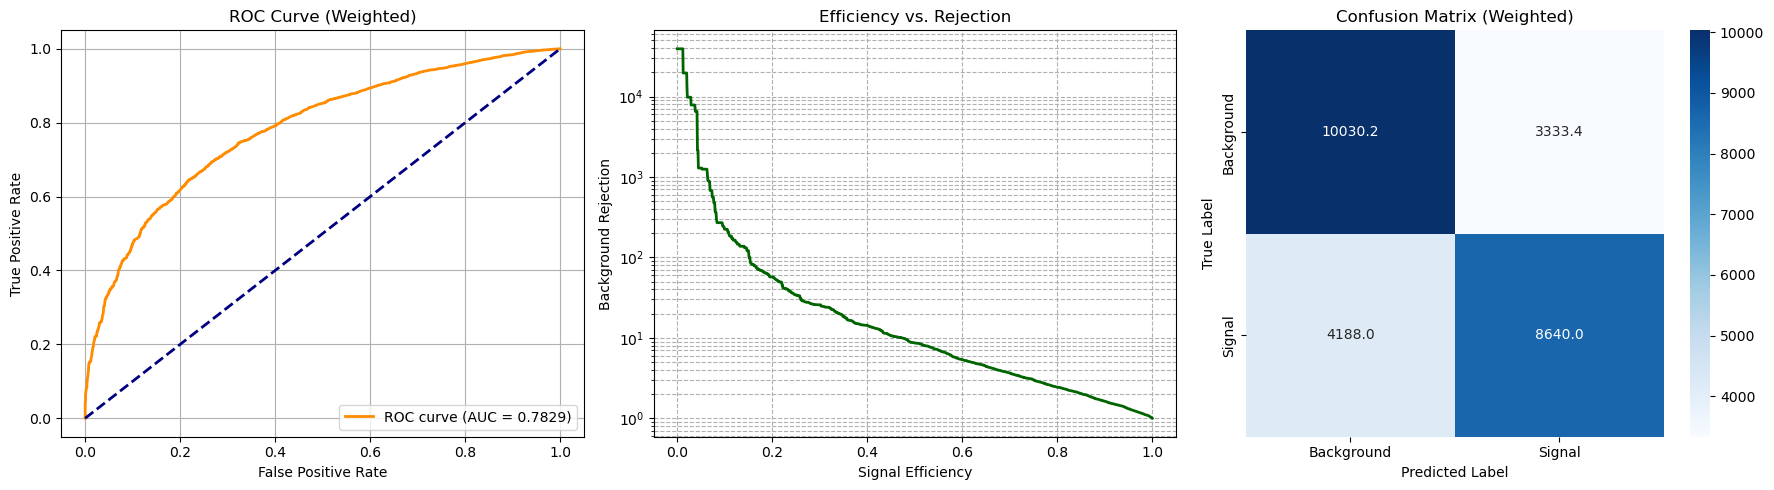

In [54]:
# ==========================================
# 4. Training Loop
# ==========================================
print("\nStarting Standalone DeepSet Training...")
EPOCHS = 100 
best_val_loss = float('inf')
patience = 12
epochs_no_improve = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    train_loss = 0
    
    # Notice: x_dnn is completely gone
    for x_set, y_batch, w_batch in train_loader:
        x_set = x_set.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        w_batch = w_batch.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            out = model(x_set)
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
        scaler.scale(loss).backward()
        
        # FIX: Gradient clipping to prevent topology spike blowouts
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * x_set.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # Validation Phase
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for x_set, y_batch, w_batch in val_loader:
            x_set = x_set.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            w_batch = w_batch.to(DEVICE, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                out = model(x_set)
                loss = weighted_bce_loss(out, y_batch, w_batch)
            
            val_loss += loss.item() * x_set.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Time: {time.time() - start_time:.1f}s")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), f"{OUTPUT_DIR}/best_standalone_deepset_model.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered! Training stopped.")
            break

print("Training Complete!")


# ==========================================
# 5. Evaluation 
# ==========================================
def evaluate_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()  
    all_labels, all_probas, all_weights = [], [], [] 

    with torch.no_grad():
        for x_set, labels, weights in data_loader:
            x_set = x_set.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(x_set)
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy()) 

    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten() 

    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET\n" + "="*60)
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve (Weighted)'); plt.legend(loc="lower right"); plt.grid(True)

    with np.errstate(divide='ignore'):
        background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
    
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log'); plt.xlabel('Signal Efficiency'); plt.ylabel('Background Rejection'); plt.title('Efficiency vs. Rejection'); plt.grid(True, which="both", ls="--")

    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) 
    plt.title('Confusion Matrix (Weighted)'); plt.ylabel('True Label'); plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

print("\nEvaluating best DeepSet model on Test Set...")
model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_standalone_deepset_model.pth"))
evaluate_model(model, test_loader, DEVICE)

In [55]:
# ==========================================
# 6. Score Entire Datasets and Save to Parquet
# ==========================================
def score_and_save_dataset(df, X_gnn_raw, scaler_gnn, model, device, output_path, batch_size=BATCH_SIZE):
    print(f"Generating DeepSet scores for {len(df)} events...")
    
    N, M, F = X_gnn_raw.shape
    X_gnn_flat = X_gnn_raw.reshape(-1, F)
    is_real = ~np.all(X_gnn_flat == 0, axis=1)
    
    X_gnn_scaled_flat = np.zeros_like(X_gnn_flat)
    if np.any(is_real):
        X_gnn_scaled_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
        
    X_gnn_scaled = X_gnn_scaled_flat.reshape(N, M, F)
    
    tensor_ds = TensorDataset(
        torch.as_tensor(X_gnn_scaled, dtype=torch.float32)
    )
    loader = DataLoader(tensor_ds, batch_size=batch_size, shuffle=False)
    
    model.eval()
    all_probas = []
    
    with torch.no_grad():
        for x_set_batch in loader:
            x_set = x_set_batch[0].to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                outputs = model(x_set)
                probas = torch.sigmoid(outputs)
            all_probas.extend(probas.cpu().numpy())
            
    df_scored = df.copy() 
    df_scored['deepset_score'] = np.array(all_probas).flatten()
    df_scored.to_parquet(output_path, engine='pyarrow', index=False)
    print(f" -> Saved successfully to: {output_path}")
    return df_scored

print("\n" + "="*60 + "\nSCORING AND SAVING FULL DATASETS\n" + "="*60)
model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_standalone_deepset_model.pth"))

# df_sig_scored = score_and_save_dataset(
#     df=df_sig, 
#     X_gnn_raw=xg_sig, 
#     scaler_gnn=scaler_gnn, 
#     model=model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, 'signal_deepset_scored.parquet')
# )

# df_bkg_scored = score_and_save_dataset(
#     df=df_bkg, 
#     X_gnn_raw=xg_bg, 
#     scaler_gnn=scaler_gnn, 
#     model=model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, 'background_deepset_scored.parquet')
# )

# print("\nAll DeepSet processing complete.")


SCORING AND SAVING FULL DATASETS


/tmp/ipykernel_2853/2190070227.py:40: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_standalone_deepset_model.pth"))


<All keys matched successfully>

In [56]:
df_test_ds_scored = score_and_save_dataset(
    df=df_test_tdnn_scored, 
    X_gnn_raw=xg_test, 
    scaler_gnn=scaler_gnn, 
    model=model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, 'test_df.parquet')
)

Generating DeepSet scores for 25656 events...
 -> Saved successfully to: standalone_deepset_results/test_df.parquet


In [209]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import os

OUTPUT_DIR = 'hybrid_deepset_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

BATCH_SIZE = 128

# ==========================================
# 1. Data Scaling & DataLoaders
# ==========================================
print("Setting up DataLoaders...")

# Assuming xg_sig, xg_bg, xd_sig, xd_bg, y_sig, y_bg, w_sig, w_bg are available.
X_gnn_all = np.concatenate([xg_sig, xg_bg], axis=0)
X_dnn_all = np.concatenate([xd_sig, xd_bg], axis=0)  # Reintroduced DNN features
y_all = np.concatenate([y_sig, y_bg], axis=0)

# FIX: Absolute values to prevent inverted BCE gradients, and clipping extreme physics outliers
w_all = np.abs(np.concatenate([w_sig, w_bg], axis=0))
weight_cap = np.percentile(w_all, 99.5) 
w_all = np.clip(w_all, a_min=0, a_max=weight_cap)

# 1a. Scale DNN Features
scaler_dnn = StandardScaler()
X_dnn_all_scaled = scaler_dnn.fit_transform(X_dnn_all)

# 1b. Scale GNN/DeepSet Features (Masking out zero-padded particles)
N, M, F = X_gnn_all.shape
X_gnn_flat = X_gnn_all.reshape(-1, F)
is_real = ~np.all(X_gnn_flat == 0, axis=1) # Boolean mask for real tracks

scaler_gnn = StandardScaler()
scaler_gnn.fit(X_gnn_flat[is_real])
X_gnn_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
X_gnn_flat[~is_real] = 0.0 # Ensure padding remains exactly zero
X_gnn_all_scaled = X_gnn_flat.reshape(N, M, F)

# 1c. Data Splitting (Train 80% / Val 10% / Test 10%)
print(f"Total Combined dataset size: {len(y_all)} events")
indices = np.arange(len(y_all))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, stratify=y_all, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, stratify=y_all[temp_idx], random_state=42)

# 1d. Create PyTorch Datasets (Memory safe torch.as_tensor, WITH DNN features)
train_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.as_tensor(X_dnn_all_scaled[train_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[train_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[train_idx], dtype=torch.float32).view(-1, 1)
)
val_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.as_tensor(X_dnn_all_scaled[val_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[val_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[val_idx], dtype=torch.float32).view(-1, 1)
)
test_ds = TensorDataset(
    torch.as_tensor(X_gnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.as_tensor(X_dnn_all_scaled[test_idx], dtype=torch.float32), 
    torch.as_tensor(y_all[test_idx], dtype=torch.float32).view(-1, 1), 
    torch.as_tensor(w_all[test_idx], dtype=torch.float32).view(-1, 1)
)

# num_workers=0 and drop_last=True to prevent RAM/BatchNorm crashes
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True, drop_last=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)


# ==========================================
# 2. Model Definition (Hybrid DeepSet + DNN)
# ==========================================
class PhiNetwork(nn.Module):
    """ Processes each particle completely independently. """
    def __init__(self, input_dim, hidden_dim=64):
        super(PhiNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim)
        )
        
    def forward(self, x):
        # x is [B, N, F]. PyTorch Linears automatically broadcast over the N dimension.
        return self.net(x)

class RhoNetwork(nn.Module):
    """ Processes the globally pooled sum of all particles into a LATENT VECTOR. """
    def __init__(self, input_dim, output_dim=24):
        super(RhoNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, output_dim)
            
        )
        
    def forward(self, x):
        return self.net(x)

class DeepSetExtractor(nn.Module):
    def __init__(self, n_set_features, latent_dim=24):
        super(DeepSetExtractor, self).__init__()
        self.phi = PhiNetwork(input_dim=n_set_features, hidden_dim=64)
        self.rho = RhoNetwork(input_dim=64, output_dim=latent_dim)

    def forward(self, x):
        # 1. Identify padded particles (all features == 0.0) -> Shape: [B, N, 1]
        valid_mask = (~(x == 0).all(dim=-1)).float().unsqueeze(-1)
        
        # 2. Pass all particles through Phi
        phi_out = self.phi(x) # [B, N, 64]
        
        # 3. MASKING FIX: Multiply by 0 so padded particles add exactly 0 to the sum pool
        phi_out = phi_out * valid_mask
        
        # 4. Global Sum Pooling (The core of DeepSets)
        pooled = torch.sum(phi_out, dim=1) # [B, 64]
        
        # 5. Pass pooled representation through Rho for latent abstraction
        return self.rho(pooled) # [B, latent_dim]

class DNNBlock(nn.Module):
    def __init__(self, input_dim):
        super(DNNBlock, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(128, 64), nn.BatchNorm1d(64), nn.ReLU(), nn.Dropout(0.15),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1) # Raw Logits
        )
    def forward(self, x):
        return self.net(x)

class Hybrid_DeepSet(nn.Module):
    def __init__(self, n_set_features, n_dnn_features, latent_dim=24):
        super(Hybrid_DeepSet, self).__init__()
        
        # Branch 1: DeepSet for the constituent jets
        self.set_branch = DeepSetExtractor(n_set_features=n_set_features, latent_dim=latent_dim)
        
        # Branch 2: Final DNN evaluating the concatenation
        combined_dim = latent_dim + n_dnn_features
        self.dnn_branch = DNNBlock(input_dim=combined_dim)

    def forward(self, x_set, x_dnn):
        # Extract set representation [B, 24]
        set_embedding = self.set_branch(x_set)
        
        # Concatenate with event-level kinematics [B, 24 + n_dnn_features]
        combined_features = torch.cat([set_embedding, x_dnn], dim=1)
        
        # Final classification [B, 1]
        return self.dnn_branch(combined_features)


# ==========================================
# 3. Model Initialization
# ==========================================
set_feats = X_gnn_all_scaled.shape[2] 
dnn_feats = X_dnn_all_scaled.shape[1] 

model = Hybrid_DeepSet(
    n_set_features=set_feats,
    n_dnn_features=dnn_feats,
    latent_dim=24
).to(DEVICE)

optimizer = optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)
scaler = torch.amp.GradScaler('cuda')

def weighted_bce_loss(output, target, weight):
    loss = nn.functional.binary_cross_entropy_with_logits(output, target, reduction='none')
    weighted_loss = loss * weight
    return weighted_loss.sum() / (weight.sum() + 1e-8)

Setting up DataLoaders...
Total Combined dataset size: 511731 events


In [ ]:
# ==========================================
# 4. Training Loop
# ==========================================
print("\nStarting Hybrid DeepSet Training...")
EPOCHS = 100 
best_val_loss = float('inf')
patience = 12
epochs_no_improve = 0

for epoch in range(EPOCHS):
    start_time = time.time()
    model.train()
    train_loss = 0
    
    # Reintroduced x_dnn here
    for x_set, x_dnn, y_batch, w_batch in train_loader:
        x_set = x_set.to(DEVICE, non_blocking=True)
        x_dnn = x_dnn.to(DEVICE, non_blocking=True)
        y_batch = y_batch.to(DEVICE, non_blocking=True)
        w_batch = w_batch.to(DEVICE, non_blocking=True)
        
        optimizer.zero_grad(set_to_none=True)
        
        with torch.amp.autocast('cuda'):
            out = model(x_set, x_dnn)
            loss = weighted_bce_loss(out, y_batch, w_batch)
            
        scaler.scale(loss).backward()
        
        # FIX: Gradient clipping to prevent topology spike blowouts
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=2.0)
        
        scaler.step(optimizer)
        scaler.update()
        
        train_loss += loss.item() * x_set.size(0)
        
    train_loss /= len(train_loader.dataset)
    
    # Validation Phase
    model.eval()
    val_loss = 0
    
    with torch.no_grad():
        for x_set, x_dnn, y_batch, w_batch in val_loader:
            x_set = x_set.to(DEVICE, non_blocking=True)
            x_dnn = x_dnn.to(DEVICE, non_blocking=True)
            y_batch = y_batch.to(DEVICE, non_blocking=True)
            w_batch = w_batch.to(DEVICE, non_blocking=True)
            
            with torch.amp.autocast('cuda'):
                out = model(x_set, x_dnn)
                loss = weighted_bce_loss(out, y_batch, w_batch)
            
            val_loss += loss.item() * x_set.size(0)
            
    val_loss /= len(val_loader.dataset)
    
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    print(f"Epoch [{epoch+1}/{EPOCHS}] | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {current_lr:.6f} | Time: {time.time() - start_time:.1f}s")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), f"{OUTPUT_DIR}/best_hybrid_deepset_model.pth")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered! Training stopped.")
            break

print("Training Complete!")


# ==========================================
# 5. Evaluation 
# ==========================================
def evaluate_model(model, data_loader, device, class_names=['Background', 'Signal']):
    model.eval()  
    all_labels, all_probas, all_weights = [], [], [] 

    with torch.no_grad():
        for x_set, x_dnn, labels, weights in data_loader:
            x_set = x_set.to(device)
            x_dnn = x_dnn.to(device)
            
            with torch.amp.autocast('cuda'):
                outputs = model(x_set, x_dnn)
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy()) 

    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    y_pred_binary = (y_pred_proba > 0.5).astype(int)
    sample_weight = np.array(all_weights).flatten() 

    print("\n" + "="*60 + "\nFINAL PERFORMANCE ON TEST SET\n" + "="*60)
    print(classification_report(y_test, y_pred_binary, target_names=class_names, sample_weight=sample_weight))

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(18, 5))
    
    plt.subplot(1, 3, 1)
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve (Weighted)'); plt.legend(loc="lower right"); plt.grid(True)

    with np.errstate(divide='ignore'):
        background_rejection = np.where(fpr > 0, 1.0 / fpr, np.inf)
    
    plt.subplot(1, 3, 2)
    plt.plot(tpr, background_rejection + 1e-7, color='darkgreen', lw=2)
    plt.yscale('log'); plt.xlabel('Signal Efficiency'); plt.ylabel('Background Rejection'); plt.title('Efficiency vs. Rejection'); plt.grid(True, which="both", ls="--")

    cm = confusion_matrix(y_test, y_pred_binary, sample_weight=sample_weight)
    plt.subplot(1, 3, 3)
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues', xticklabels=class_names, yticklabels=class_names) 
    plt.title('Confusion Matrix (Weighted)'); plt.ylabel('True Label'); plt.xlabel('Predicted Label')

    plt.tight_layout()
    plt.show()

print("\nEvaluating best Hybrid DeepSet model on Test Set...")
model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_hybrid_deepset_model.pth"))
evaluate_model(model, test_loader, DEVICE)

In [210]:
# ==========================================
# 6. Score Entire Datasets and Save to Parquet
# ==========================================
def score_and_save_dataset(df, X_gnn_raw, X_dnn_raw, scaler_gnn, scaler_dnn, model, device, output_path, batch_size=BATCH_SIZE):
    print(f"Generating Hybrid DeepSet scores for {len(df)} events...")
    
    N, M, F = X_gnn_raw.shape
    X_gnn_flat = X_gnn_raw.reshape(-1, F)
    is_real = ~np.all(X_gnn_flat == 0, axis=1)
    
    X_gnn_scaled_flat = np.zeros_like(X_gnn_flat)
    if np.any(is_real):
        X_gnn_scaled_flat[is_real] = scaler_gnn.transform(X_gnn_flat[is_real])
        
    X_gnn_scaled = X_gnn_scaled_flat.reshape(N, M, F)
    X_dnn_scaled = scaler_dnn.transform(X_dnn_raw)
    
    tensor_ds = TensorDataset(
        torch.as_tensor(X_gnn_scaled, dtype=torch.float32),
        torch.as_tensor(X_dnn_scaled, dtype=torch.float32)
    )
    loader = DataLoader(tensor_ds, batch_size=batch_size, shuffle=False)
    
    model.eval()
    all_probas = []
    
    with torch.no_grad():
        for x_set, x_dnn in loader:
            x_set = x_set.to(device, non_blocking=True)
            x_dnn = x_dnn.to(device, non_blocking=True)
            with torch.amp.autocast('cuda'):
                outputs = model(x_set, x_dnn)
                probas = torch.sigmoid(outputs)
            all_probas.extend(probas.cpu().numpy())
            
    df_scored = df.copy() 
    df_scored['hybrid_deepset_score'] = np.array(all_probas).flatten()
    df_scored.to_parquet(output_path, engine='pyarrow', index=False)
    print(f" -> Saved successfully to: {output_path}")
    return df_scored

print("\n" + "="*60 + "\nSCORING AND SAVING FULL DATASETS\n" + "="*60)
model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_hybrid_deepset_model.pth"))

# df_sig_ddnn_scored = score_and_save_dataset(
#     df=df_sig, 
#     X_gnn_raw=xg_sig, 
#     X_dnn_raw=xd_sig,
#     scaler_gnn=scaler_gnn, 
#     scaler_dnn=scaler_dnn,
#     model=model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, 'signal_hybrid_deepset_scored.parquet')
# )

# df_bkg_ddnn_scored = score_and_save_dataset(
#     df=df_bkg, 
#     X_gnn_raw=xg_bg, 
#     X_dnn_raw=xd_bg,
#     scaler_gnn=scaler_gnn, 
#     scaler_dnn=scaler_dnn,
#     model=model, 
#     device=DEVICE, 
#     output_path=os.path.join(OUTPUT_DIR, 'background_hybrid_deepset_scored.parquet')
# )

# print("\nAll Hybrid DeepSet processing complete.")


SCORING AND SAVING FULL DATASETS


/tmp/ipykernel_166/1229445933.py:43: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"{OUTPUT_DIR}/best_hybrid_deepset_model.pth"))


<All keys matched successfully>

In [211]:
df_test_ddnn_scored = score_and_save_dataset(
    df=df_test_ds_scored, 
    X_gnn_raw=xg_test, 
    X_dnn_raw=xd_test,
    scaler_gnn=scaler_gnn, 
    scaler_dnn=scaler_dnn,
    model=model, 
    device=DEVICE, 
    output_path=os.path.join(OUTPUT_DIR, 'test_df.parquet')
)

Generating Hybrid DeepSet scores for 51174 events...
 -> Saved successfully to: hybrid_deepset_results/test_df.parquet


In [24]:
df_sig_ds = pl.read_parquet("standalone_deepset_results/signal_deepset_scored.parquet").to_pandas()

In [25]:
df_bkg_ds = pl.read_parquet("standalone_deepset_results/background_deepset_scored.parquet").to_pandas()

In [26]:
df_sig_all_scored = pl.read_parquet("tdnn_combined_results/sig_reco_large.parquet").to_pandas()
df_bkg_all_scored = pl.read_parquet("tdnn_combined_results/bkg_reco_large.parquet").to_pandas()

In [105]:
df_sig_all_scored['t_score'] = df_sig_t_scored['t_score']
df_bkg_all_scored['t_score'] = df_bkg_t_scored['t_score']

In [137]:
df_sig_all_scored['tdnn_score'] = df_sig_tdnn_scored['tdnn_score']
df_bkg_all_scored['tdnn_score'] = df_bkg_tdnn_scored['tdnn_score']

In [146]:
df_sig_all_scored['gdnn_score'] = df_sig_gdnn_scored['gdnn_score']
df_bkg_all_scored['gdnn_score'] = df_bkg_gdnn_scored['gdnn_score']

In [147]:
df_sig_all_scored.to_parquet('sig_scored.parquet', engine='pyarrow', index=False)
df_bkg_all_scored.to_parquet('bkg_scored.parquet', engine='pyarrow', index=False)

print("Both dataframes have been saved to Parquet!")

Both dataframes have been saved to Parquet!


In [213]:
df_test_ddnn_scored.to_parquet('test_scored.parquet', engine='pyarrow', index=False)

In [ ]:
df_test_ds_scored.to_parquet('truth_test_scored.parquet', engine='pyarrow', index = False)

In [95]:
# ==========================================
# 3. Learning Curve Automation 
# ==========================================

def get_fresh_model_and_optimizer():
    """Initializes a completely new model, optimizer, scheduler, and scaler."""
    base_model = ParticleTransformer(n_features=X_gnn_all_scaled.shape[2]) 
    model = AutoMaskedTransformer(base_model).to(DEVICE)
    
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)
    scaler = torch.amp.GradScaler('cuda')
    
    return model, optimizer, scheduler, scaler

def train_for_fraction(train_loader_subset, val_loader, fraction_label):
    """Runs your exact training loop for a specific data subset."""
    print(f"\n{'-'*40}\nTraining on {fraction_label*100:.0f}% of Data\n{'-'*40}")
    
    model, optimizer, scheduler, scaler = get_fresh_model_and_optimizer()
    
    EPOCHS = 100 
    best_val_loss = float('inf')
    patience = 12
    epochs_no_improve = 0
    model_save_path = f"{OUTPUT_DIR}/best_transformer_frac_{fraction_label:.2f}.pth"

    for epoch in range(EPOCHS):
        # --- Training ---
        model.train()
        train_loss = 0
        
        for xg, xd, y_batch, w_batch in train_loader_subset:
            xg, y_batch, w_batch = xg.to(DEVICE), y_batch.to(DEVICE), w_batch.to(DEVICE)
            
            optimizer.zero_grad(set_to_none=True)
            
            with torch.amp.autocast('cuda'):
                out = model(xg)
                loss = weighted_bce_loss(out, y_batch, w_batch)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            train_loss += loss.item() * xg.size(0)
            
        train_loss /= len(train_loader_subset.dataset)
        
        # --- Validation ---
        model.eval()
        val_loss = 0
        
        with torch.no_grad():
            for xg, xd, y_batch, w_batch in val_loader:
                xg, y_batch, w_batch = xg.to(DEVICE), y_batch.to(DEVICE), w_batch.to(DEVICE)
                
                with torch.amp.autocast('cuda'):
                    out = model(xg)
                    loss = weighted_bce_loss(out, y_batch, w_batch)
                
                val_loss += loss.item() * xg.size(0)
                
        val_loss /= len(val_loader.dataset)
        
        scheduler.step(val_loss)
        
        # Early Stopping Logic
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(model.state_dict(), model_save_path)
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}.")
                break
                
    return model_save_path

# Modify your evaluate function to return the AUC
def evaluate_and_get_auc(model_path, data_loader):
    model, _, _, _ = get_fresh_model_and_optimizer()
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    all_labels, all_probas, all_weights = [], [], []

    with torch.no_grad():
        for xg, xd, labels, weights in data_loader:
            xg = xg.to(DEVICE)
            with torch.amp.autocast('cuda'):
                outputs = model(xg)
                probas = torch.sigmoid(outputs)
                
            all_labels.extend(labels.cpu().numpy())
            all_probas.extend(probas.cpu().numpy())
            all_weights.extend(weights.cpu().numpy()) 

    y_test = np.array(all_labels).flatten()
    y_pred_proba = np.array(all_probas).flatten()
    sample_weight = np.array(all_weights).flatten() 

    fpr, tpr, _ = roc_curve(y_test, y_pred_proba, sample_weight=sample_weight)
    return auc(fpr, tpr)

In [101]:
# ==========================================
# 4. Execute Learning Curve Experiment
# ==========================================

data_fractions = [0.05, 0.1, 0.25, 0.5, 0.75, 1.0]
results_auc = []
training_sizes = []

for frac in data_fractions:
    # 1. Stratified subset of the training indices
    if frac == 1.0:
        subset_idx = train_idx
    else:
        # Stratify ensures we keep the same Signal/Background ratio in the smaller datasets
        subset_idx, _ = train_test_split(
            train_idx, train_size=frac, stratify=y_all[train_idx], random_state=42
        )
    
    training_sizes.append(len(subset_idx))
    
    # 2. Create the subset dataset and loader
    subset_ds = TensorDataset(
        torch.tensor(X_gnn_all_scaled[subset_idx], dtype=torch.float32), 
        torch.tensor(X_dnn_all_scaled[subset_idx], dtype=torch.float32), 
        torch.tensor(y_all[subset_idx].copy(), dtype=torch.float32).view(-1, 1), 
        torch.tensor(w_all[subset_idx].copy(), dtype=torch.float32).view(-1, 1)
    )
    
    train_loader_subset = DataLoader(
        subset_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True
    )
    
    # 3. Train from scratch and save the model
    best_model_path = train_for_fraction(train_loader_subset, val_loader, frac)
    
    # 4. Evaluate on the STATIC test set
    test_auc = evaluate_and_get_auc(best_model_path, test_loader)
    results_auc.append(test_auc)
    print(f"-> Test AUC for {frac*100:.0f}% data: {test_auc:.4f}")


----------------------------------------
Training on 5% of Data
----------------------------------------
Early stopping triggered at epoch 23.


/tmp/ipykernel_2853/2340635428.py:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


-> Test AUC for 5% data: 0.7435

----------------------------------------
Training on 10% of Data
----------------------------------------
Early stopping triggered at epoch 24.


/tmp/ipykernel_2853/2340635428.py:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


-> Test AUC for 10% data: 0.7553

----------------------------------------
Training on 25% of Data
----------------------------------------
Early stopping triggered at epoch 28.


...

-> Test AUC for 50% data: 0.7687

----------------------------------------
Training on 75% of Data
----------------------------------------
Early stopping triggered at epoch 23.


/tmp/ipykernel_2853/2340635428.py:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


-> Test AUC for 75% data: 0.7791

----------------------------------------
Training on 100% of Data
----------------------------------------
Early stopping triggered at epoch 29.


/tmp/ipykernel_2853/2340635428.py:84: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


-> Test AUC for 100% data: 0.7825


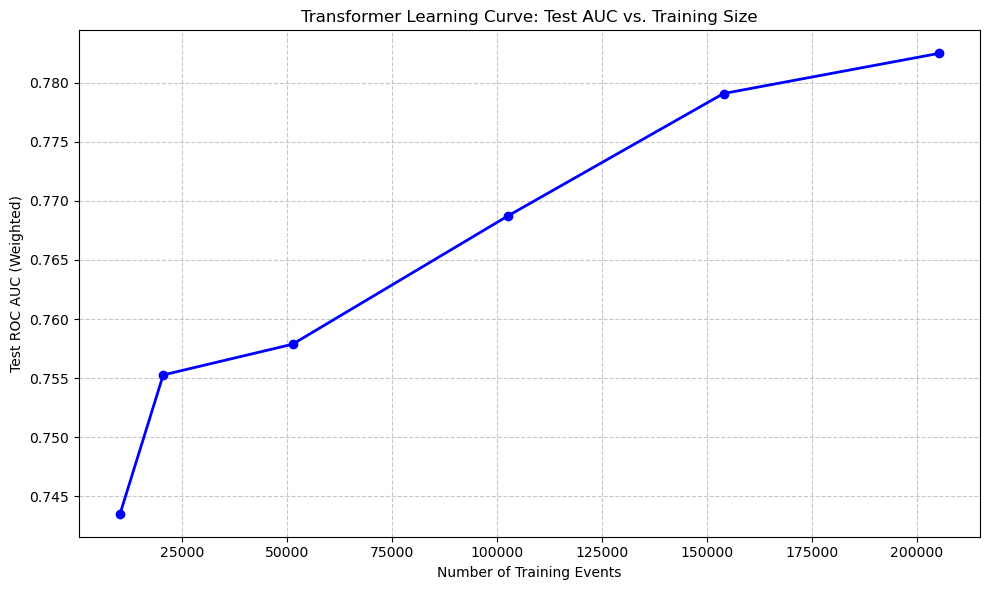

In [103]:
# ==========================================
# 5. Plot the Learning Curve
# ==========================================

plt.figure(figsize=(10, 6))
plt.plot(training_sizes, results_auc, marker='o', linestyle='-', linewidth=2, color='b')
plt.title('Transformer Learning Curve: Test AUC vs. Training Size')
plt.xlabel('Number of Training Events')
plt.ylabel('Test ROC AUC (Weighted)')
plt.grid(True, linestyle='--', alpha=0.7)

# Optional: Log scale x-axis can sometimes make the asymptotic behavior clearer
# plt.xscale('log') 

plt.tight_layout()
plt.show()